# 논문의 빈도주의 통계분석을 베이즈 통계로 다시 하기 — Stan (cmdstanpy) 판

**대상 논문**: 이선빈·김지현(2025), 「학부 유학생의 한국어 쓰기 효능감·호감도·상위인지 전략 사용 양상 연구」, 『작문연구』 65, 7-41.
**데이터**: `survey_data.csv` — 논문의 기술통계를 재현하도록 생성한 시뮬레이션 설문 자료(172명, 5점 리커트 51문항).
**사후분포 샘플링**: Stan (cmdstanpy). **그림**: matplotlib + seaborn.

이 노트북의 목적은 *같은 자료, 같은 질문*에 대해 논문이 SPSS 로 낸 빈도주의 결과(점추정치, 표준오차, p-값, F, 별표)를 **베이즈 방식으로 다시 계산하고, 베이즈 논문이라면 그 결과를 어떻게 제시하고 설명해야 하는지**를 익히는 것이다. 앞의 노트북(`paper_replication_frequentist.ipynb`)과 짝을 이룬다.

| 논문의 표 | 빈도주의 (논문) | 베이즈 대응 (이 노트북) | 절 |
|---|---|---|---|
| <표 1>, <표 4> | 빈도, 비율 | 디리클레–다항 모형 → 비율의 사후분포와 95 % 신용구간 | 3 |
| <표 5>, <표 6> | 평균 M, 표준편차 SD | 정규모형 → μ, σ 의 사후분포, 사후예측검사 | 4 |
| <표 3> | Cronbach's α (점추정) | 다변량 정규 + LKJ 사전분포 → α 의 사후분포, $P(\alpha>0.8)$ | 5 |
| <표 7> | 피어슨 r, $p<.001$ 별표 | 다변량 정규 + LKJ → 상관행렬의 사후분포, $P(\rho>0)$ | 6 |
| <표 8>, <표 9> | 일원분산분석 F, p, Scheffé | 집단 평균 모형 → 평균 차이의 사후분포, $P(\delta>0)$, ROPE, 효과크기 | 7 |
| <표 10> | 회귀 B, SE, β, t, p, VIF, R² | 베이즈 회귀 → 계수의 사후분포, $P(B>0)$, 베이즈 R², 사전분포에 의한 정칙화 | 8 |

**진행 방식**: 각 절마다 ① 논문 표 캡처 → ② 베이즈 모형(사전분포·우도)과 그 직관 → ③ 코드(모형 정의, 샘플링, 수렴 진단) → ④ 사후분포 요약과 그림 → ⑤ "베이즈 논문이라면 이렇게 쓴다"는 보고 문장 예시, 의 순서로 진행한다.

## 1. 베이즈 추론의 틀 — 빈도주의 결과와 무엇이 어떻게 달라지는가

### 1-1. 한 장의 그림: 사전분포 × 우도 ∝ 사후분포

모수(평균 μ, 상관 ρ, 회귀계수 B …)를 $\theta$, 자료를 $D$ 라 할 때

$$
\underbrace{p(\theta \mid D)}_{\text{사후분포}} \;=\; \frac{\overbrace{p(D\mid\theta)}^{\text{우도}}\;\overbrace{p(\theta)}^{\text{사전분포}}}{p(D)} \;\propto\; p(D\mid\theta)\,p(\theta)
$$

- **빈도주의**: $\theta$ 는 고정된 미지의 상수. 확률은 "표본을 다시 뽑았을 때"에만 붙는다. 그래서 결과는 점추정치 $\hat\theta$, 그 표본 변동을 나타내는 표준오차, "$\theta=0$ 이라면 이런 자료가 나올 확률" 인 p-값으로 보고된다.
- **베이즈**: $\theta$ 자체에 확률분포를 둔다. 자료를 보기 전의 믿음(**사전분포**)을 자료의 정보(**우도**)로 갱신한 결과가 **사후분포**이고, 모든 결론은 이 분포 하나에서 나온다. "μ 가 3.2 와 3.4 사이에 있을 확률은 95 %", "차이가 0 보다 클 확률은 99.8 %" 처럼 **모수에 대한 확률 문장**을 직접 말할 수 있다.

### 1-2. 논문 표의 각 칸이 베이즈에서는 무엇으로 바뀌는가

| 빈도주의 보고 항목 | 베이즈 보고 항목 | 읽는 법 |
|---|---|---|
| 점추정치 (M, r, B, α) | **사후 평균** 또는 **사후 중앙값** | 사후분포의 중심 |
| 표준오차 S.E. | **사후 표준편차** | 모수에 대한 불확실성의 폭 |
| 95 % 신뢰구간 | **95 % 신용구간** (credible interval; 등꼬리 CI 또는 최고밀도구간 HDI) | "모수가 이 구간 안에 있을 확률이 95 %" — 신뢰구간에는 허용되지 않는 바로 그 해석 |
| p-값, 별표 (*, **) | **사후확률** $P(\theta>0\mid D)$, 또는 ROPE 안에 있을 확률 | "효과가 양(+)일 확률 99.8 %" |
| F 검정, Scheffé | 집단 평균 차이 $\delta$ 의 사후분포, $P(\delta>0)$ | 검정이 아니라 **추정**으로 답한다 |
| VIF, D–W 등 가정 진단 | 사후예측검사(posterior predictive check), 계수 사후분포의 상관 | 모형이 자료를 재현하는가 |
| (없음) | **R̂ (R-hat), ESS, 발산(divergence)** | MCMC 가 사후분포를 제대로 탐색했는가 — 반드시 보고 |
| (없음) | **사전분포 명세** | 어떤 사전 믿음을 넣었는지 — 반드시 보고 |

### 1-3. 사후분포를 얻는 방법: MCMC (NUTS)

사후분포는 대부분 닫힌 식이 없다. 대신 사후분포에서 **표본을 수천 개 뽑아** 그 표본으로 평균·분위수·확률을 계산한다. 이 노트북은 Hamiltonian Monte Carlo 계열의 **NUTS** 샘플러를 쓴다(4 체인 × 예열 1000 + 표본 1000 = 4000 개 사후 표본). 표본이 사후분포를 대표하는지 확인하는 세 가지 진단이 있다.

- **R̂ (split R-hat)**: 체인 간 분산과 체인 내 분산의 비. 서로 다른 시작점에서 출발한 체인들이 같은 분포로 섞였으면 1.00 에 가깝다. **1.01 이하**여야 한다.
- **ESS (effective sample size)**: 자기상관을 제거하고 남는 "독립 표본에 해당하는 개수". 400 이상이면 사후 요약이 안정적이다.
- **발산 전이(divergent transitions)**: 0 이어야 한다. 있으면 사후분포에 샘플러가 못 들어가는 영역이 있다는 뜻이다.

### 1-4. 사전분포에 대한 태도

이 노트북은 모든 모형에 **약한 정보(weakly informative) 사전분포**를 쓴다: 5점 척도 평균에 $\mu \sim N(3, 2)$, 표준편차에 반정규 $\sigma \sim N^+(0, 2)$, 상관행렬에 LKJ(2), 회귀계수에 $N(0,1)$. 이는 "μ 가 −100 이나 +100 일 리는 없다" 수준의 상식만 담고 자료가 결론을 이끌게 두는 선택이며, $N=172$ 에서는 사후분포가 우도(즉 빈도주의 추정)와 거의 같아진다. **그래서 이 노트북의 사후 평균은 논문의 점추정치와 거의 일치하고, 달라지는 것은 그 값에 붙는 불확실성의 표현과 해석**이다. 사전분포가 결과를 실제로 바꾸는 상황(다중공선성이 있는 회귀)은 8절에서 일부러 보여 준다.

## 2. 준비 — 라이브러리, 데이터, 공용 도구

**설치**: `pip install cmdstanpy` 후 `python -m cmdstanpy.install_cmdstan` (C++ 컴파일러 필요: macOS 는 Xcode command line tools, Windows 는 RTools). 아래 셀은 CmdStan 이 없으면 설치를 시도한다.

**공용 도구** (두 노트북 공통, numpy 로 직접 구현):

- `hdi(x, 0.95)` — 최고밀도구간(HDI): 사후표본을 정렬해 95 %를 담는 **가장 짧은** 구간. 등꼬리 구간(2.5 %, 97.5 % 분위수)과 달리 비대칭 분포에서도 밀도가 높은 쪽을 담는다.
- `split_rhat(chains)`, `ess(chains)` — 1-3 절의 수렴 진단을 정의식대로 구현(각 체인을 반으로 쪼갠 뒤 체인 간/내 분산 비; 자기상관 합으로 유효표본수).
- `summarize(post, name)` — 사후 평균·SD·중앙값·95 % HDI·R̂·ESS 를 한 표로.
- `trace(post, name)` — 체인별 추적 그림(trace plot)과 사후밀도.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import warnings, logging, pathlib, time
warnings.filterwarnings("ignore")

# 한글 글꼴
_avail = {f.name for f in font_manager.fontManager.ttflist}
_kor = next((f for f in ["AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"] if f in _avail),
            next((f for f in sorted(_avail) if "CJK" in f or "Gothic" in f), "DejaVu Sans"))
sns.set_theme(style="whitegrid", font=_kor, rc={"axes.unicode_minus": False, "figure.dpi": 110})
BLUE, ORANGE, GRAY, DARK = "#2a78d6", "#eb6834", "#c3c2b7", "#0b0b0b"

df = pd.read_csv("survey_data.csv")
N = len(df)
SUB = {"발상": [f"SE{i:02d}" for i in range(1, 6)], "규칙": [f"SE{i:02d}" for i in range(6, 11)], "자기조절": [f"SE{i:02d}" for i in range(11, 17)],
       "긍정": ["LW17", "LW19"], "부정": ["LW18", "LW20"],
       "계획": [f"MC{i:02d}" for i in range(1, 11)], "작성": [f"MC{i:02d}" for i in range(11, 21)], "검토": [f"MC{i:02d}" for i in range(21, 32)]}
names = list(SUB)
S = np.column_stack([df[c].to_numpy(float).mean(axis=1) for c in SUB.values()])     # 하위 척도 점수 (172 × 8)

# ---------- 공용 도구 ----------
def hdi(x, prob=0.95):
    x = np.sort(np.asarray(x).ravel()); n = len(x); m = int(np.floor(prob * n))
    j = np.argmin(x[m:] - x[:n - m]); return x[j], x[j + m]

def split_rhat(chains):                      # chains: (C, T)
    C, T = chains.shape; h = T // 2
    x = np.concatenate([chains[:, :h], chains[:, h:2 * h]], axis=0)
    W = x.var(axis=1, ddof=1).mean(); B = h * x.mean(axis=1).var(ddof=1)
    return np.sqrt(((h - 1) / h * W + B / h) / W)

def ess(chains):                             # Geyer 초기 양수열 (Stan 방식의 근사)
    C, T = chains.shape
    xc = chains - chains.mean(axis=1, keepdims=True)
    acov = np.empty((C, T))
    for c in range(C):
        f = np.fft.rfft(xc[c], n=2 * T); acov[c] = np.fft.irfft(f * np.conj(f), n=2 * T)[:T] / T
    mean_var = acov[:, 0].mean() * T / (T - 1)
    var_plus = mean_var * (T - 1) / T + (chains.mean(axis=1).var(ddof=1) if C > 1 else 0)
    rho = 1 - (mean_var - acov.mean(axis=0)) / var_plus
    tau, t = -1.0, 0
    while t + 1 < T:
        P = rho[t] + rho[t + 1]
        if P < 0: break
        tau += 2 * P; t += 2
    return C * T / max(tau, 1e-9)

def flat(post, name):                        # (C, T, ...) -> (C*T, ...)
    a = post[name]; return a.reshape((-1,) + a.shape[2:])

def summarize(post, name, labels=None, prob=0.95):
    a = post[name]; C, T = a.shape[:2]; a2 = a.reshape(C, T, -1)
    rows = []
    for j in range(a2.shape[2]):
        d = a2[:, :, j]; lo, hi = hdi(d, prob)
        rows.append([d.mean(), d.std(ddof=1), np.median(d), lo, hi, split_rhat(d), ess(d)])
    idx = labels if labels is not None else ([name] if a2.shape[2] == 1 else [f"{name}[{j}]" for j in range(a2.shape[2])])
    return pd.DataFrame(rows, index=idx, columns=["사후평균", "사후SD", "중앙값", f"HDI {prob:.0%} 하한", f"HDI {prob:.0%} 상한", "R̂", "ESS"])

def trace(post, name, idx=(), title=None):
    a = post[name][(slice(None), slice(None)) + tuple(idx)]
    fig, ax = plt.subplots(1, 2, figsize=(10, 2.8), gridspec_kw={"width_ratios": [2, 1]})
    for c in range(a.shape[0]):
        ax[0].plot(a[c], lw=.5, alpha=.8, label=f"chain {c+1}")
        sns.kdeplot(a[c], ax=ax[1], lw=1.2)
    ax[0].set(title=f"trace: {title or name}", xlabel="iteration"); ax[0].legend(fontsize=7, ncol=4, frameon=False)
    ax[1].set(title="체인별 사후밀도", ylabel="")
    plt.tight_layout(); plt.show()

print("N =", N, " 하위 척도 점수 S:", S.shape)

N = 172  하위 척도 점수 S: (172, 8)


### 2-1. Stan 백엔드

Stan 모형은 `data`(자료), `parameters`(추정할 모수), `model`(사전분포와 우도), `generated quantities`(모수의 함수) 블록으로 쓴다.
`run_stan(name, code, data)` 는 Stan 코드를 `stan/<name>.stan` 파일로 저장하고 컴파일한 뒤 NUTS 로 4 체인을 돌리고, 사후표본을 `post[변수] = (체인, 반복, ...)` 모양의 numpy 배열로 돌려준다. 이 뒤의 모든 후처리는 이 배열만 사용하므로 NumPyro 판 노트북과 완전히 같다.

In [2]:
import cmdstanpy
cmdstanpy.utils.get_logger().setLevel(logging.ERROR)   # 예열 초기 단계의 무해한 경고 숨김
try:
    cmdstanpy.cmdstan_path()
except ValueError:
    cmdstanpy.install_cmdstan(cores=2)            # CmdStan 이 없으면 설치 (수 분 소요)
print("CmdStan:", cmdstanpy.cmdstan_path())

STAN_DIR = pathlib.Path("stan"); STAN_DIR.mkdir(exist_ok=True)
CHAINS, WARMUP, SAMPLES = 4, 1000, 1000

def run_stan(name, code, data, seed=2025, inits=None):
    path = STAN_DIR / f"{name}.stan"
    if not path.exists() or path.read_text() != code.strip() + "\n":
        path.write_text(code.strip() + "\n")
    model = cmdstanpy.CmdStanModel(stan_file=str(path))
    t0 = time.time()
    fit = model.sample(data=data, chains=CHAINS, iter_warmup=WARMUP, iter_sampling=SAMPLES, seed=seed, show_progress=False, inits=inits)
    post = {}
    for v in fit.stan_variables():                        # draws 는 체인 순서로 이어져 있음 -> (C, T, ...)
        a = fit.stan_variable(v); post[v] = a.reshape((CHAINS, SAMPLES) + a.shape[1:])
    ndiv = int(fit.divergences.sum()) if hasattr(fit, "divergences") else int(fit.method_variables()["divergent__"].sum())
    print(f"[{name}] 표본추출 {time.time()-t0:.1f}s,  발산 전이 = {ndiv}")
    return fit, post

CmdStan: /root/.cmdstan/cmdstan-2.36.0


## 3. <표 1>·<표 4> 비율 → 디리클레–다항 모형

**빈도주의 보고**: "베트남 108명(62.8 %)". 이 62.8 % 는 표본 비율이고, 논문은 그 불확실성을 보고하지 않는다.

**베이즈 모형**. $K$ 개 범주의 도수 $n = (n_1,\dots,n_K)$ 는 모집단 비율 $\theta=(\theta_1,\dots,\theta_K)$, $\sum\theta_k=1$ 을 갖는 다항분포를 따른다고 보고, $\theta$ 에 디리클레 사전분포를 둔다.

$$
n \sim \text{Multinomial}(N, \theta), \qquad \theta \sim \text{Dirichlet}(a_1,\dots,a_K)
$$

- $a_k = 1$ 은 "모든 비율 조합이 똑같이 그럴듯하다"는 균일 사전분포다. 사후분포는 $\text{Dirichlet}(a_k + n_k)$ 로 닫힌 식이 있지만, 여기서는 이후 모형과 같은 절차를 익히기 위해 MCMC 로 뽑는다.
- **직관**: 사전분포의 $a_k$ 는 "미리 관찰한 가상의 표본 수"다. $a_k=1$ 이면 범주마다 1명을 미리 본 셈이라 $N=172$ 앞에서는 거의 영향이 없다.
- **보고 방식**: 점추정 대신 "베트남 61 % [95 % HDI 54–68]" 처럼 **사후 평균과 신용구간**을 쓴다. 특히 소수 범주(러시아 6명)의 구간이 상대적으로 얼마나 넓은지가 그대로 드러난다 — 빈도주의 표에서는 보이지 않던 정보다.

첫 모형이므로 **수렴 진단**(R̂, ESS, trace plot)도 함께 자세히 본다.

**논문 원문 캡처** — <표 1> 연구 대상자 기본 정보

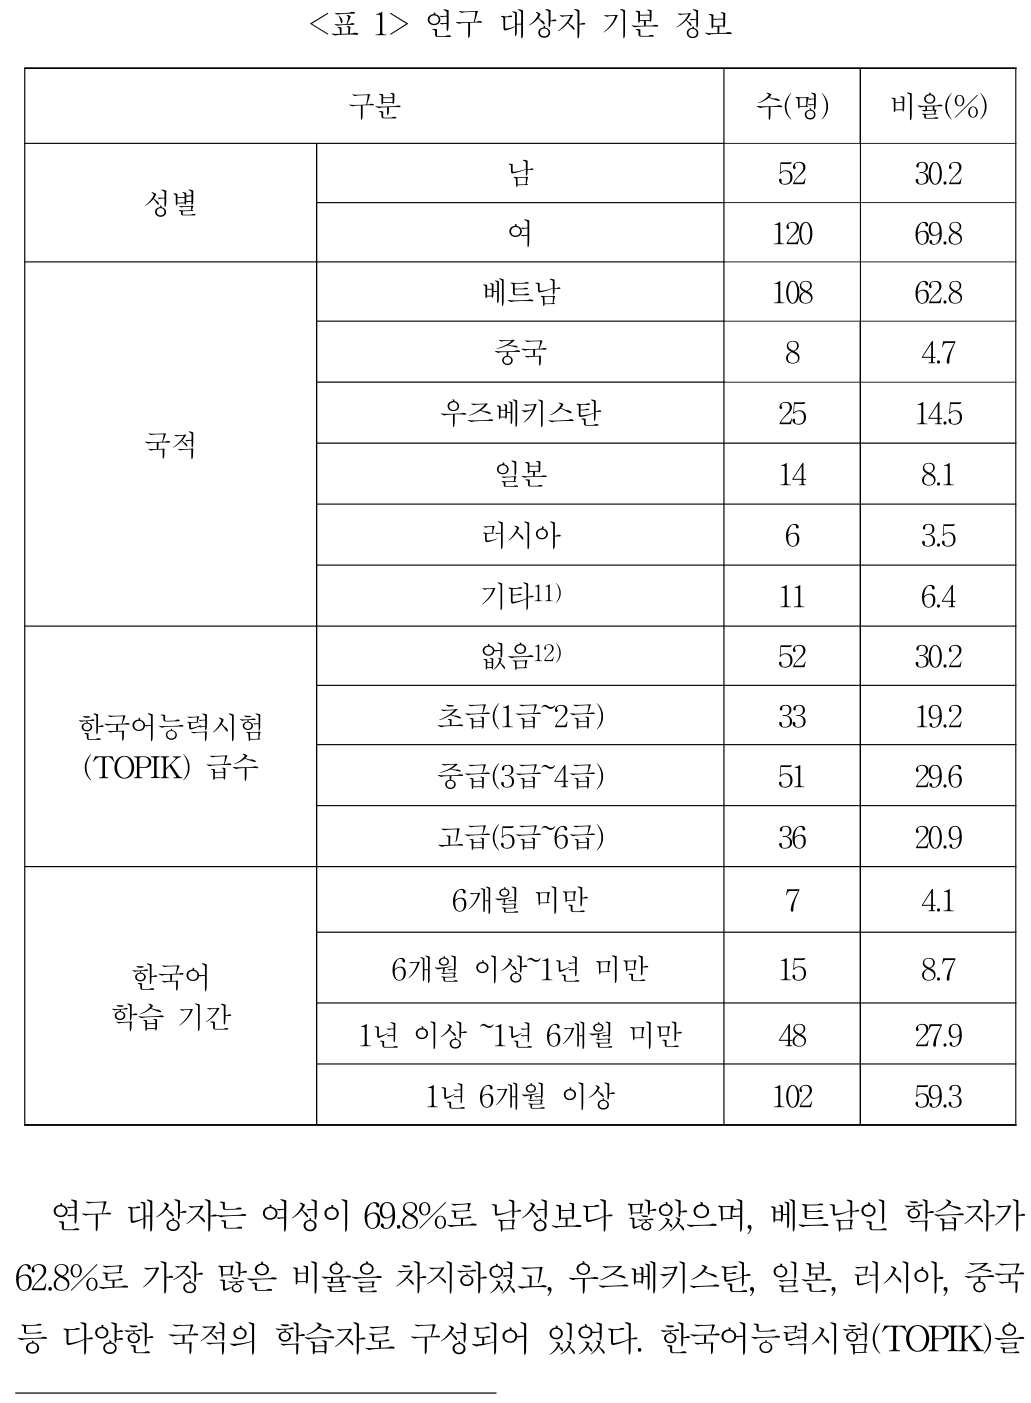

In [3]:
stan_prop = """
data {
  int<lower=1> K;                 // 범주 수
  array[K] int<lower=0> n;        // 범주별 도수
  vector<lower=0>[K] a;           // 디리클레 사전분포 모수
}
parameters {
  simplex[K] theta;               // 비율 (합 = 1)
}
model {
  theta ~ dirichlet(a);           // 사전분포
  n ~ multinomial(theta);         // 우도
}
"""
nat_labels = ["베트남", "중국", "우즈베키스탄", "일본", "러시아", "기타"]
n_nat = np.bincount(df["nationality"].to_numpy(), minlength=7)[1:]
fit_nat, post_nat = run_stan("proportions", stan_prop, {"K": 6, "n": n_nat.tolist(), "a": [1.0] * 6})

[proportions] 표본추출 0.7s,  발산 전이 = 0


### 3-1. 수렴 진단 읽기

아래 표의 R̂ 이 모두 1.01 이하이고 ESS 가 수천이면 4000개 표본을 사후분포의 대표 표본으로 믿어도 된다. trace plot 에서는 네 체인이 같은 띠 안에서 "굵은 털뭉치"처럼 겹쳐 있어야 하고, 오른쪽 체인별 밀도 곡선 네 개가 거의 포개져야 한다. 이 그림은 **베이즈 논문의 부록에 반드시 들어가는 그림**이다.

        표본 비율(논문 %) (%)  사후평균 (%)  사후SD (%)  중앙값 (%)  HDI 95% 하한 (%)  HDI 95% 상한 (%)
베트남                62.8      61.2       3.6     61.3            54.1            68.3
중국                  4.7       5.1       1.6      4.9             2.2             8.3
우즈베키스탄             14.5      14.6       2.7     14.5             9.6            20.1
일본                  8.1       8.4       2.0      8.2             4.7            12.4
러시아                 3.5       3.9       1.5      3.8             1.3             6.8
기타                  6.4       6.8       1.9      6.6             3.2            10.5
           R̂       ESS
베트남     1.000  5164.322
중국      1.000  5278.434
우즈베키스탄  1.000  5422.163
일본      1.000  4069.307
러시아     1.000  4565.638
기타      0.999  5132.122


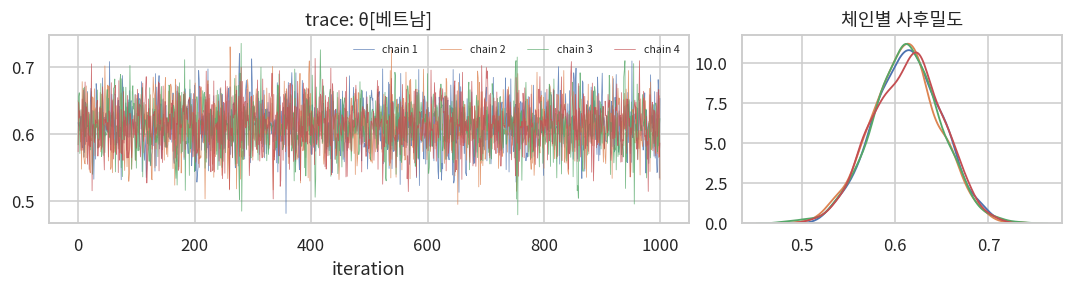

In [4]:
tab_nat = summarize(post_nat, "theta", labels=nat_labels)
tab_nat.insert(0, "표본 비율(논문 %)", n_nat / N)
print((tab_nat.iloc[:, :6] * 100).round(1).rename(columns=lambda c: c + " (%)" if c != "R̂" else c).to_string())
print(tab_nat[["R̂", "ESS"]].round(3).to_string())
trace(post_nat, "theta", (0,), title="θ[베트남]")

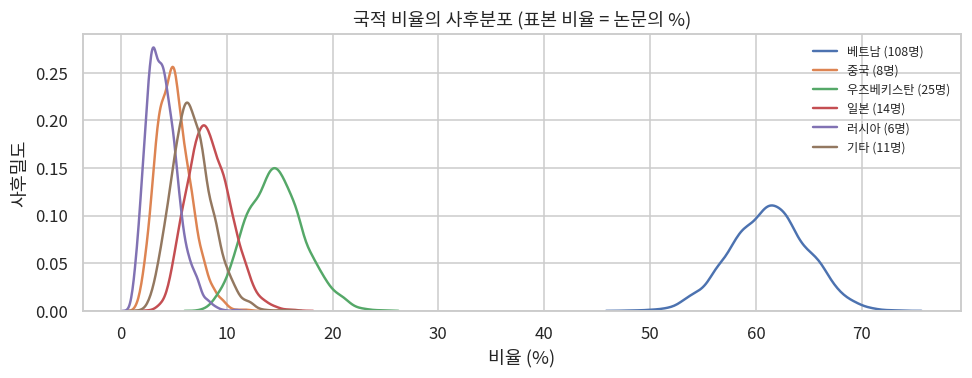

In [5]:
th = flat(post_nat, "theta")
fig, ax = plt.subplots(figsize=(9, 3.6))
for j, lab in enumerate(nat_labels):
    sns.kdeplot(th[:, j] * 100, ax=ax, lw=1.6, label=f"{lab} ({n_nat[j]}명)")
ax.set(title="국적 비율의 사후분포 (표본 비율 = 논문의 %)", xlabel="비율 (%)", ylabel="사후밀도")
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

**베이즈 논문이라면 <표 1> 을 이렇게 쓴다**: "국적은 베트남이 가장 많았다(108명, 사후 평균 61.2 %, 95 % HDI [54.1, 68.3]). 균일 디리클레 사전분포를 사용했으며, 4 체인 NUTS 표본 4000개, 모든 R̂ ≤ 1.01." — 논문의 62.8 % 와 사후 평균이 거의 같지만(사전분포의 1명씩 때문에 아주 조금 3분의 1 쪽으로 당겨진다), 이제 그 값이 얼마나 확실한지도 함께 말한다.

같은 모형으로 TOPIK 급수 분포도 구해 두자(7절의 집단 비교에서 집단 크기의 불확실성을 떠올리는 데 쓰인다).

In [6]:
topik_labels = ["없음", "초급", "중급", "고급"]
n_top = np.bincount(df["topik"].to_numpy(), minlength=4)
_, post_top = run_stan("proportions", stan_prop, {"K": 4, "n": n_top.tolist(), "a": [1.0] * 4})
t = summarize(post_top, "theta", labels=topik_labels); t.insert(0, "표본 비율", n_top / N)
print((t.iloc[:, :6] * 100).round(1).to_string())

[proportions] 표본추출 0.1s,  발산 전이 = 0
    표본 비율  사후평균  사후SD   중앙값  HDI 95% 하한  HDI 95% 상한
없음   30.2  30.1   3.4  30.1        23.5        36.7
초급   19.2  19.3   3.0  19.2        13.3        24.8
중급   29.7  29.5   3.4  29.4        23.1        36.3
고급   20.9  21.1   3.1  21.0        14.8        26.9


## 4. <표 5>·<표 6> 평균과 표준편차 → 정규모형

**빈도주의 보고**: 발상 M = 3.29, SD = 0.73. 두 숫자 모두 점추정치이며, 논문은 M 의 표준오차($SD/\sqrt{N} \approx 0.056$)도, SD 의 불확실성도 적지 않는다.

**베이즈 모형**. 하위 척도 점수 $y_{is}$ 가 척도 $s$ 마다 평균 $\mu_s$, 표준편차 $\sigma_s$ 인 정규분포를 따른다고 본다.

$$
y_{is} \sim N(\mu_s, \sigma_s), \qquad \mu_s \sim N(3, 2), \qquad \sigma_s \sim N^+(0, 2)
$$

- $\mu_s$ 의 사후분포는 "모집단 평균이 어디쯤인가"에 대한 믿음이다. 사후 SD 는 빈도주의의 표준오차와 거의 같은 값이 되지만 **의미가 다르다**: 표준오차는 "표본을 다시 뽑으면 M 이 이만큼 흔들린다"이고, 사후 SD 는 "지금 자료를 본 뒤 모평균이 이만큼 불확실하다"이다.
- $\sigma_s$ 에도 사후분포가 생긴다. 빈도주의 표에서 SD 는 그냥 숫자 하나지만, 베이즈에서는 "개인차의 크기"도 추정 대상이라 신용구간을 붙인다. 논문이 "부정적 태도의 SD 가 가장 크다"고 해석한 주장은 $P(\sigma_{부정} > \sigma_{긍정}\mid D)$ 같은 사후확률로 뒷받침할 수 있다.
- **사후예측검사**: 사후표본에서 뽑은 $(\mu, \sigma)$ 로 가상의 자료 $y^{rep}$ 를 생성해 실제 자료와 겹쳐 본다. 모형이 자료의 모양(1~5 범위, 봉우리 위치)을 재현하는지 눈으로 확인하는 절차로, 빈도주의의 "정규성 검정"에 해당하지만 훨씬 직접적이다.

**논문 원문 캡처** — <표 5> 쓰기 효능감, 호감도, 상위인지 전략 기술통계 결과

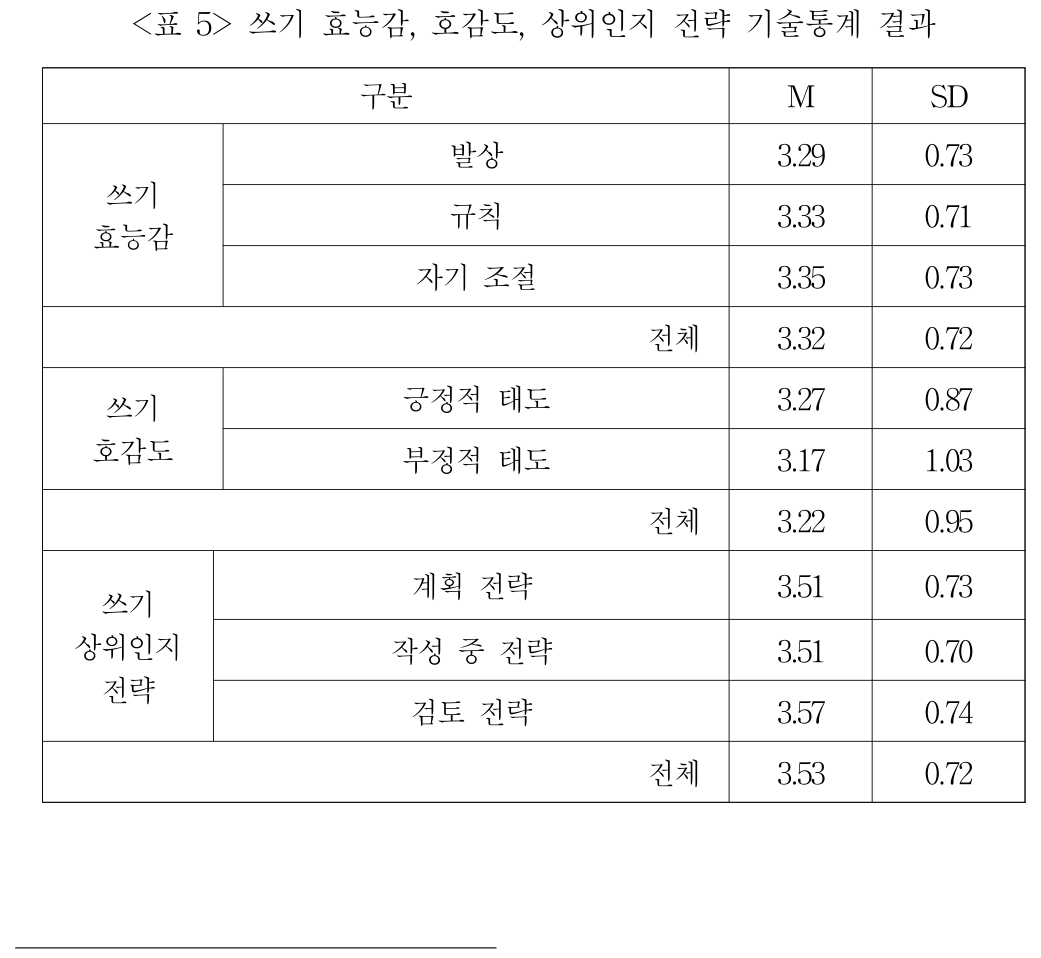

### 4-1. 가장 단순한 확률모형 하나 — 열 하나(하위 척도 하나)의 평균과 표준편차

먼저 **변수 하나**만 놓고 생각한다. 발상 효능감 점수 172개 $y_1,\dots,y_N$ 이 있을 때, 모형은 다음 세 줄이 전부다.

$$
y_i \sim N(\mu,\ \sigma) \quad (i=1,\dots,N), \qquad \mu \sim N(3,\ 2), \qquad \sigma \sim N^+(0,\ 2)
$$

이 세 줄을 **자료가 생겨나는 이야기**로 읽으면: "어딘가에 모평균 μ 와 모표준편차 σ 가 있다(무엇인지는 모른다). 자료를 보기 전 내 믿음은 μ 가 3 근처 ±2 쯤, σ 는 0~2 사이 어디쯤이다. 학생 한 명의 점수는 그 μ 를 중심으로 σ 만큼 흩어진 정규분포에서 하나씩 뽑힌 것이다." — 이것이 우도(첫 줄)와 사전분포(둘째·셋째 줄)이고, 베이즈 정리는 이 이야기와 실제 자료 172개를 결합해 "μ 와 σ 가 무엇이었을 가능성이 큰가"(사후분포)를 돌려준다.

아래 프로그램은 이 세 줄을 거의 그대로 옮긴 것이다. `data` 는 관측된 것, `parameters` 는 모르는 것, `model` 은 모르는 것과 관측된 것의 확률적 관계다. 8개 하위 척도에 대해서는 **같은 프로그램을 파이썬 반복문으로 8번** 실행한다 — 프로그램은 "변수 하나의 모형"만 알고, 8개라는 사실은 파이썬 쪽에만 있다.

In [7]:
stan_mean_single = """
data {
  int<lower=1> N;                 // 관측된 것: 학생 수
  vector[N] y;                    //            학생들의 점수 (하위 척도 하나)
}
parameters {
  real mu;                        // 모르는 것: 모평균
  real<lower=0> sigma;            //            모표준편차 (0 이상)
}
model {
  mu ~ normal(3, 2);              // 자료를 보기 전의 믿음 (사전분포)
  sigma ~ normal(0, 2);           //   하한이 0 이므로 실제로는 반정규분포
  y ~ normal(mu, sigma);          // 자료가 생겨나는 방식 (우도): 점수 하나하나가 N(mu, sigma) 에서
}
"""
post_single = {}
for j, n in enumerate(names):                                   # 8개 하위 척도에 대해 같은 모형을 8번
    _, post_single[n] = run_stan("mean_single", stan_mean_single, {"N": N, "y": S[:, j]})

[mean_single] 표본추출 0.1s,  발산 전이 = 0
[mean_single] 표본추출 0.1s,  발산 전이 = 0


[mean_single] 표본추출 0.1s,  발산 전이 = 0
[mean_single] 표본추출 0.1s,  발산 전이 = 0


[mean_single] 표본추출 0.1s,  발산 전이 = 0
[mean_single] 표본추출 0.1s,  발산 전이 = 0


[mean_single] 표본추출 0.1s,  발산 전이 = 0
[mean_single] 표본추출 0.1s,  발산 전이 = 0


       표본평균  M(논문)  μ 사후평균  μ 사후SD  HDI 하한  HDI 상한   표본SD  σ 사후평균  R̂(μ)
발상    3.287   3.29   3.284   0.058   3.169   3.398  0.733   0.740  1.004
규칙    3.330   3.33   3.329   0.056   3.226   3.445  0.704   0.709  1.000
자기조절  3.350   3.35   3.349   0.056   3.242   3.462  0.733   0.739  1.000
긍정    3.267   3.27   3.269   0.068   3.134   3.401  0.874   0.881  0.999
부정    3.166   3.17   3.165   0.081   3.009   3.324  1.033   1.040  0.999
계획    3.510   3.51   3.509   0.055   3.402   3.617  0.733   0.740  1.000
작성    3.512   3.51   3.513   0.054   3.411   3.624  0.701   0.706  1.001
검토    3.570   3.57   3.570   0.058   3.451   3.680  0.742   0.747  1.000


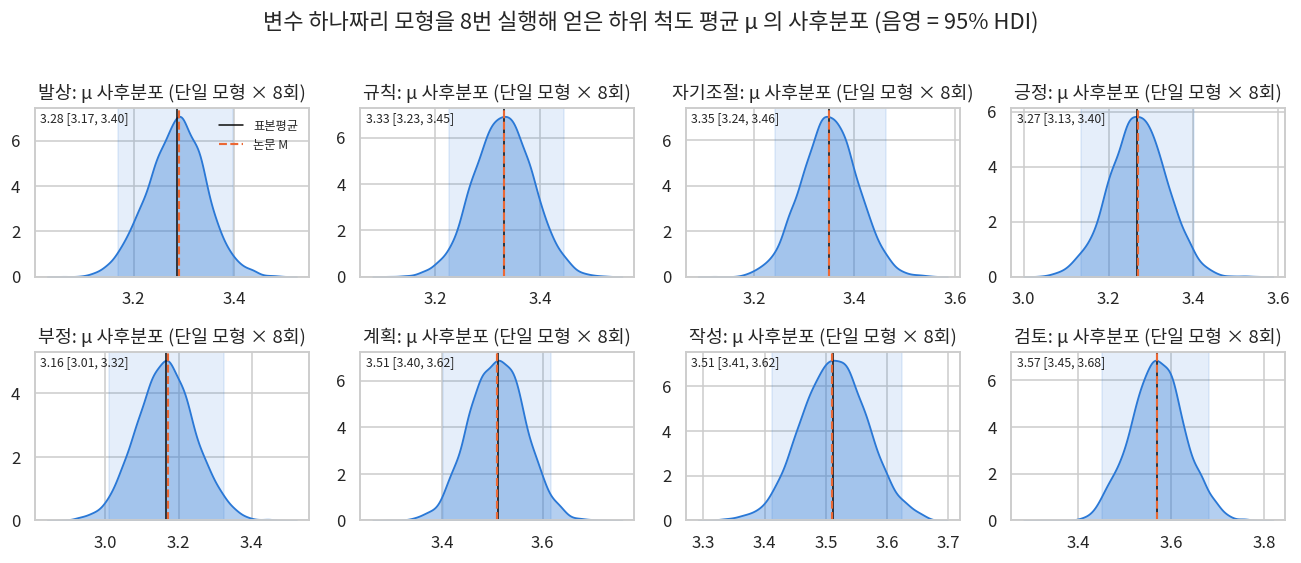

In [8]:
paper5 = {"발상": (3.29, .73), "규칙": (3.33, .71), "자기조절": (3.35, .73), "긍정": (3.27, .87), "부정": (3.17, 1.03), "계획": (3.51, .73), "작성": (3.51, .70), "검토": (3.57, .74)}
rows = []
for j, n in enumerate(names):
    m = flat(post_single[n], "mu"); sg = flat(post_single[n], "sigma"); lo, hi = hdi(m)
    rows.append([S[:, j].mean(), paper5[n][0], m.mean(), m.std(ddof=1), lo, hi, S[:, j].std(ddof=1), sg.mean(), split_rhat(post_single[n]["mu"])])
print(pd.DataFrame(rows, index=names, columns=["표본평균", "M(논문)", "μ 사후평균", "μ 사후SD", "HDI 하한", "HDI 상한", "표본SD", "σ 사후평균", "R̂(μ)"]).round(3).to_string())

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for j, (ax, n) in enumerate(zip(axes.ravel(), names)):
    m = flat(post_single[n], "mu")
    sns.kdeplot(m, ax=ax, fill=True, color=BLUE, alpha=.35, lw=1.2)
    lo, hi = hdi(m); ax.axvspan(lo, hi, color=BLUE, alpha=.12)
    ax.axvline(S[:, j].mean(), color=DARK, ls="-", lw=1, label="표본평균")
    ax.axvline(paper5[n][0], color=ORANGE, ls="--", lw=1.4, label="논문 M")
    ax.set(title=f"{n}: μ 사후분포 (단일 모형 × 8회)", xlabel="", ylabel="")
    ax.text(.02, .92, f"{m.mean():.2f} [{lo:.2f}, {hi:.2f}]", transform=ax.transAxes, fontsize=8)
axes[0, 0].legend(frameon=False, fontsize=8)
plt.suptitle("변수 하나짜리 모형을 8번 실행해 얻은 하위 척도 평균 μ 의 사후분포 (음영 = 95% HDI)", y=1.02); plt.tight_layout(); plt.show()

**읽기.** 여덟 패널은 서로 완전히 독립된 여덟 번의 추론이다. 각 패널에서 사후분포의 중심은 표본평균(검은 실선)과 거의 같고 논문의 M(주황 점선)과도 일치한다 — 172개의 자료 앞에서 $N(3,2)$ 라는 느슨한 사전분포는 거의 아무 역할도 하지 않는다. 사후분포의 폭(사후 SD ≈ 0.055)은 빈도주의의 표준오차 $s/\sqrt{N}$ 과 같은 크기이지만 의미가 다르다: "이 자료를 본 뒤 모평균이 이 범위 안에 있을 확률이 95 %"다. 부정적 호감도의 곡선이 다른 것보다 넓은 이유는 그 척도의 개인차(σ ≈ 1.03)가 가장 크기 때문이다.

### 4-2. 같은 모형을 8열에 한 번에 — 계산상의 편의일 뿐, 확률모형은 같다

아래 프로그램은 위의 단일 모형을 열 개수 `S` 만큼 **병렬로 나열**한 것이다. `mu` 와 `sigma` 가 길이 8 의 벡터가 되고, `for (s in 1:S)` 가 열마다 같은 우도를 적용한다. 열 사이에 정보를 공유하는 항이 없으므로(하위 척도 간 상관이 우도에 없다) 결과는 4-1 과 같아야 하며, 아래 표에서 실제로 같은지 확인한다. 이후 절에서는 이 벡터 판을 쓴다 — 코드가 짧고 컴파일·샘플링이 한 번이기 때문이지, 모형이 달라서가 아니다.

In [9]:
stan_means = """
data {
  int<lower=1> N;
  int<lower=1> S;
  matrix[N, S] y;                 // 하위 척도 점수 (열마다 독립적으로 추정)
}
parameters {
  vector[S] mu;
  vector<lower=0>[S] sigma;
}
model {
  mu ~ normal(3, 2);              // 약한 정보 사전분포
  sigma ~ normal(0, 2);           // 하한 0 이므로 반정규
  for (s in 1:S) y[:, s] ~ normal(mu[s], sigma[s]);
}
"""
fit_mean, post_mean = run_stan("means", stan_means, {"N": N, "S": 8, "y": S})

[means] 표본추출 0.4s,  발산 전이 = 0


In [10]:
cmp = pd.DataFrame({"μ 단일모형×8": [flat(post_single[n], "mu").mean() for n in names], "μ 벡터모형": flat(post_mean, "mu").mean(axis=0),
                    "σ 단일모형×8": [flat(post_single[n], "sigma").mean() for n in names], "σ 벡터모형": flat(post_mean, "sigma").mean(axis=0)}, index=names)
print(cmp.round(3).to_string())
print("\n두 방식의 사후평균 최대 차이: μ %.3f, σ %.3f  (몬테카를로 오차 수준)" % ((cmp.iloc[:, 0] - cmp.iloc[:, 1]).abs().max(), (cmp.iloc[:, 2] - cmp.iloc[:, 3]).abs().max()))

      μ 단일모형×8  μ 벡터모형  σ 단일모형×8  σ 벡터모형
발상       3.284   3.287     0.740   0.738
규칙       3.329   3.330     0.709   0.710
자기조절     3.349   3.350     0.739   0.739
긍정       3.269   3.267     0.881   0.880
부정       3.165   3.165     1.040   1.041
계획       3.509   3.509     0.740   0.738
작성       3.513   3.513     0.706   0.706
검토       3.570   3.569     0.747   0.748

두 방식의 사후평균 최대 차이: μ 0.003, σ 0.002  (몬테카를로 오차 수준)


In [11]:
paper5 = {"발상": (3.29, .73), "규칙": (3.33, .71), "자기조절": (3.35, .73), "긍정": (3.27, .87), "부정": (3.17, 1.03), "계획": (3.51, .73), "작성": (3.51, .70), "검토": (3.57, .74)}
tm = summarize(post_mean, "mu", labels=names); ts = summarize(post_mean, "sigma", labels=names)
tab5 = pd.DataFrame({"M(논문)": [paper5[n][0] for n in names], "μ 사후평균": tm["사후평균"], "μ 사후SD": tm["사후SD"],
                     "μ 95% HDI": [f"[{lo:.2f}, {hi:.2f}]" for lo, hi in zip(tm.iloc[:, 3], tm.iloc[:, 4])],
                     "SD(논문)": [paper5[n][1] for n in names], "σ 사후평균": ts["사후평균"],
                     "σ 95% HDI": [f"[{lo:.2f}, {hi:.2f}]" for lo, hi in zip(ts.iloc[:, 3], ts.iloc[:, 4])],
                     "R̂(μ)": tm["R̂"], "ESS(μ)": tm["ESS"]}, index=names)
print(tab5.round(3).to_string())
print(f"\n빈도주의 표준오차 SD/√N (발상) = {S[:,0].std(ddof=1)/np.sqrt(N):.3f}  vs  μ 사후SD = {tm.loc['발상','사후SD']:.3f}")

      M(논문)  μ 사후평균  μ 사후SD     μ 95% HDI  SD(논문)  σ 사후평균     σ 95% HDI  R̂(μ)     ESS(μ)
발상     3.29   3.287   0.057  [3.18, 3.40]    0.73   0.738  [0.66, 0.81]  1.000   8389.773
규칙     3.33   3.330   0.055  [3.23, 3.44]    0.71   0.710  [0.63, 0.78]  0.999   9166.926
자기조절   3.35   3.350   0.057  [3.24, 3.46]    0.73   0.739  [0.66, 0.82]  0.999   9003.784
긍정     3.27   3.267   0.067  [3.13, 3.39]    0.87   0.880  [0.79, 0.97]  0.999  10722.859
부정     3.17   3.165   0.077  [3.01, 3.31]    1.03   1.041  [0.94, 1.15]  0.999  10236.203
계획     3.51   3.509   0.058  [3.40, 3.62]    0.73   0.738  [0.66, 0.82]  0.999   8994.527
작성     3.51   3.513   0.054  [3.41, 3.62]    0.70   0.706  [0.64, 0.78]  1.000   9700.241
검토     3.57   3.569   0.059  [3.45, 3.68]    0.74   0.748  [0.67, 0.83]  0.999   9515.570

빈도주의 표준오차 SD/√N (발상) = 0.056  vs  μ 사후SD = 0.057


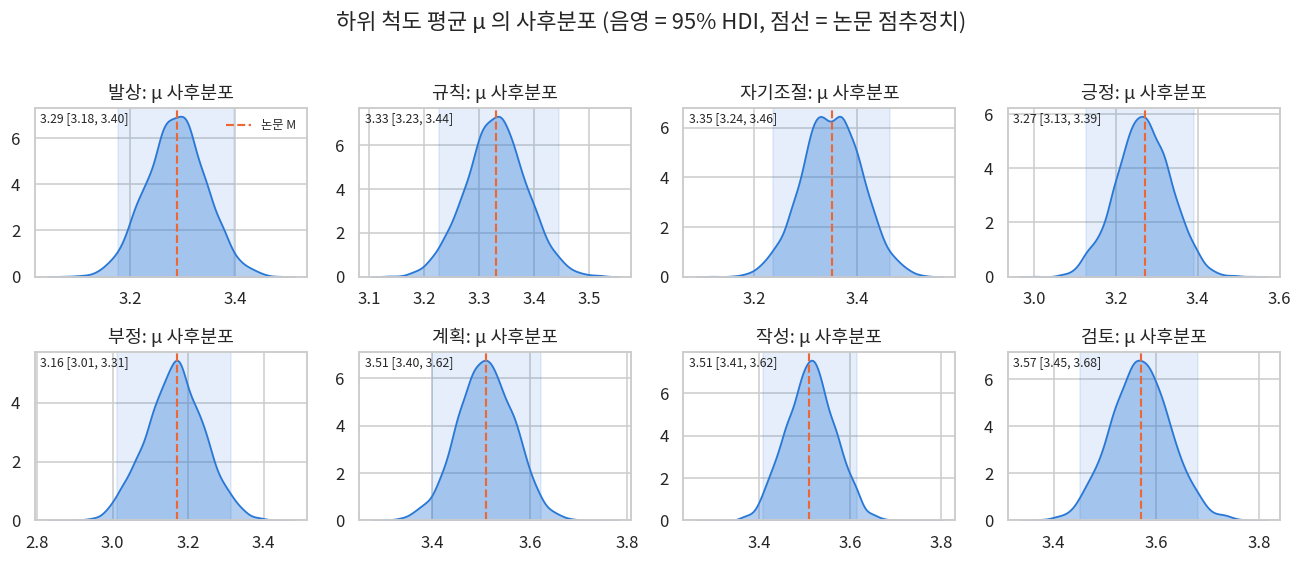

In [12]:
# 8개 하위 척도 μ 의 사후분포 + 논문의 M (점선)
mu = flat(post_mean, "mu")
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=False)
for j, (ax, n) in enumerate(zip(axes.ravel(), names)):
    sns.kdeplot(mu[:, j], ax=ax, fill=True, color=BLUE, alpha=.35, lw=1.2)
    lo, hi = hdi(mu[:, j]); ax.axvspan(lo, hi, color=BLUE, alpha=.12)
    ax.axvline(paper5[n][0], color=ORANGE, ls="--", lw=1.4, label="논문 M")
    ax.set(title=f"{n}: μ 사후분포", ylabel="", xlabel="")
    ax.text(.02, .92, f"{mu[:,j].mean():.2f} [{lo:.2f}, {hi:.2f}]", transform=ax.transAxes, fontsize=8)
axes[0, 0].legend(frameon=False, fontsize=8)
plt.suptitle("하위 척도 평균 μ 의 사후분포 (음영 = 95% HDI, 점선 = 논문 점추정치)", y=1.02); plt.tight_layout(); plt.show()

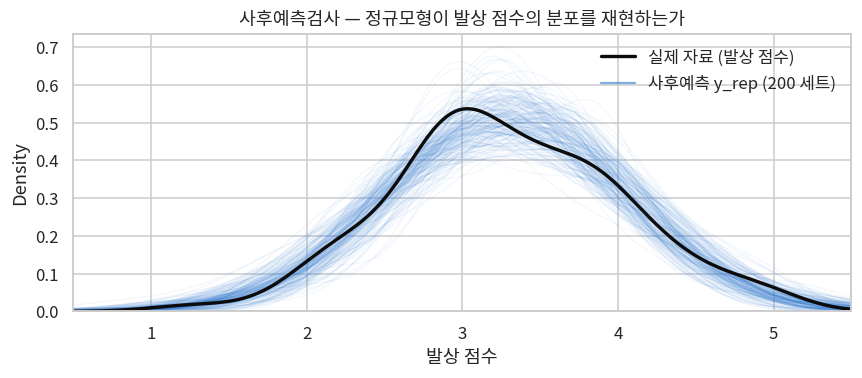

실제 자료 범위 1~5 를 벗어나는 사후예측값의 비율 ≈ 1.1%  (정규모형의 한계: 절단 척도를 연속으로 취급)


In [13]:
# 사후예측검사: 발상 점수. 사후표본 (μ, σ) 200개로 가상 자료를 만들어 실제 자료의 분포와 비교
rng = np.random.default_rng(0)
j = names.index("발상"); sig = flat(post_mean, "sigma")
idx = rng.choice(len(mu), 200, replace=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
for k in idx:
    yrep = rng.normal(mu[k, j], sig[k, j], N)
    sns.kdeplot(yrep, ax=ax, color=BLUE, alpha=.06, lw=.8)
sns.kdeplot(S[:, j], ax=ax, color=DARK, lw=2.2, label="실제 자료 (발상 점수)")
ax.plot([], [], color=BLUE, alpha=.6, label="사후예측 y_rep (200 세트)")
ax.set(title="사후예측검사 — 정규모형이 발상 점수의 분포를 재현하는가", xlabel="발상 점수", xlim=(0.5, 5.5)); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print("실제 자료 범위 1~5 를 벗어나는 사후예측값의 비율 ≈ %.1f%%  (정규모형의 한계: 절단 척도를 연속으로 취급)" %
      (100 * np.mean([(lambda r: ((r < 1) | (r > 5)).mean())(rng.normal(mu[k, j], sig[k, j], N)) for k in idx])))

**표준편차에 대한 주장을 사후확률로**. 논문은 "부정적 태도의 표준편차(1.03)가 가장 크다"고 썼다. 베이즈에서는 이것을 $P(\sigma_{부정} > \sigma_{s} \mid D)$ 로 각 척도에 대해 계산해 "가장 크다"는 주장이 얼마나 확실한지 숫자로 붙인다. 사후표본이 있으면 이런 계산은 **비교하려는 두 열의 표본을 빼서 0보다 큰 비율을 세는 것**뿐이다 — 어떤 새로운 검정도 필요 없다.

In [14]:
j_neg = names.index("부정")
probs = {n: np.mean(sig[:, j_neg] > sig[:, k]) for k, n in enumerate(names) if k != j_neg}
print("P(σ_부정 > σ_s | D):"); print(pd.Series(probs).round(3).to_string())
print(f"\nP(σ_부정 가 8개 중 최대 | D) = {np.mean(sig.argmax(axis=1) == j_neg):.3f}")

P(σ_부정 > σ_s | D):
발상      1.000
규칙      1.000
자기조절    1.000
긍정      0.986
계획      1.000
작성      1.000
검토      1.000

P(σ_부정 가 8개 중 최대 | D) = 0.986


### 4-1. <표 6> 문항 수준 — 같은 모형을 문항에 적용

논문 <표 6> 은 척도군마다 평균이 가장 높은/낮은 문항을 골랐다. 같은 정규모형을 여섯 문항에 적용하면 각 문항 평균의 사후분포가 나오고, "15번이 4번보다 높다"는 순위 주장도 $P(\mu_{15} > \mu_4 \mid D)$ 로 표현된다.
(문항은 1~5 정수라 정규모형은 근사다. 더 정확히는 순서형(ordered probit/logit) 모형을 쓰며, 그 확장은 이 노트북의 범위 밖이다.)

**논문 원문 캡처** — <표 6> 항목별 상위, 하위 1순위 문항

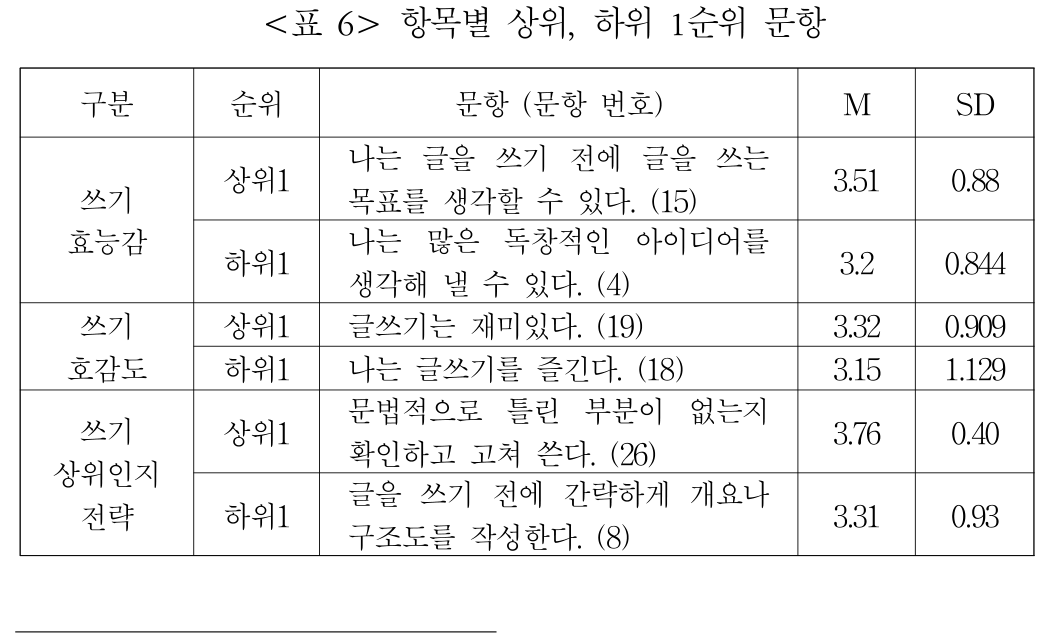

In [15]:
items6 = ["SE15", "SE04", "LW19", "LW18", "MC26", "MC08"]
paper6 = {"SE15": (3.51, .880), "SE04": (3.20, .844), "LW19": (3.32, .909), "LW18": (3.15, 1.129), "MC26": (3.76, .400), "MC08": (3.31, .930)}
_, post_item = run_stan("means", stan_means, {"N": N, "S": 6, "y": df[items6].to_numpy(float)})

[means] 표본추출 0.2s,  발산 전이 = 0


In [16]:
ti = summarize(post_item, "mu", labels=items6); tsi = summarize(post_item, "sigma", labels=items6)
tab6 = pd.DataFrame({"M(논문)": [paper6[i][0] for i in items6], "μ 사후평균": ti["사후평균"],
                     "μ 95% HDI": [f"[{lo:.2f}, {hi:.2f}]" for lo, hi in zip(ti.iloc[:, 3], ti.iloc[:, 4])],
                     "SD(논문)": [paper6[i][1] for i in items6], "σ 사후평균": tsi["사후평균"], "R̂": ti["R̂"]}, index=items6)
print(tab6.round(3).to_string())
mi = flat(post_item, "mu")
print(f"\nP(μ_SE15 > μ_SE04 | D) = {np.mean(mi[:,0] > mi[:,1]):.3f},   P(μ_LW19 > μ_LW18) = {np.mean(mi[:,2] > mi[:,3]):.3f},   P(μ_MC26 > μ_MC08) = {np.mean(mi[:,4] > mi[:,5]):.3f}")

      M(논문)  μ 사후평균     μ 95% HDI  SD(논문)  σ 사후평균     R̂
SE15   3.51   3.504  [3.37, 3.64]   0.880   0.888  0.999
SE04   3.20   3.204  [3.07, 3.33]   0.844   0.851  0.999
LW19   3.32   3.319  [3.18, 3.45]   0.909   0.922  1.000
LW18   3.15   3.144  [2.98, 3.30]   1.129   1.141  0.999
MC26   3.76   3.768  [3.71, 3.83]   0.400   0.427  1.000
MC08   3.31   3.313  [3.18, 3.46]   0.930   0.935  0.999

P(μ_SE15 > μ_SE04 | D) = 0.999,   P(μ_LW19 > μ_LW18) = 0.950,   P(μ_MC26 > μ_MC08) = 1.000


## 5. <표 3> Cronbach's α → 측정모형(1요인)으로 공분산행렬을 추정하기

**빈도주의 보고**: 발상 α = .901. 표본 하나에서 계산한 점추정치이며, "0.8 이상이므로 양호"라는 판단에 불확실성이 붙지 않는다.

**왜 모형이 필요한가**. α 는 문항 공분산행렬 $\Sigma$ 의 함수다:

$$
\alpha = \frac{k}{k-1}\left(1 - \frac{\operatorname{tr}(\Sigma)}{\mathbf{1}^\top\Sigma\,\mathbf{1}}\right)
$$

따라서 $\Sigma$ 의 사후분포를 구하면 α 의 사후분포가 **자동으로** 따라 나온다. 문제는 $\Sigma$ 에 어떤 모형과 사전분포를 두느냐다. 한 하위 척도의 문항들은 "하나의 구성개념을 재기 위해 만든 것"이므로, 심리측정에서 표준적인 **1요인(congeneric) 측정모형**을 쓴다:

$$
x_{ij} = \mu_j + \lambda_j\,\eta_i + \varepsilon_{ij}, \quad \eta_i\sim N(0,1),\ \varepsilon_{ij}\sim N(0,\psi_j^2)
\;\;\Longrightarrow\;\;
\Sigma = \lambda\lambda^\top + \operatorname{diag}(\psi^2)
$$

- $\lambda_j$ 는 문항 $j$ 가 공통요인 $\eta$ (예: 발상 효능감)를 얼마나 강하게 반영하는지(요인부하량), $\psi_j$ 는 문항 고유의 잡음이다. 사전분포는 $\mu_j\sim N(3,2)$, $\lambda_j\sim N^+(0,2)$, $\psi_j\sim N^+(0,2)$ — $\lambda_j>0$ 제약은 "모든 문항이 같은 방향으로 채점되었다"는 사실을 반영하며 부호 불확정성을 없앤다.
- 요인 $\eta_i$ 를 적분해 없앤 주변 우도 $x_i\sim N_k(\mu, \lambda\lambda^\top+\operatorname{diag}\psi^2)$ 를 쓰면 모수가 $3k$ 개뿐이라 샘플링이 빠르고 안정적이다.
- 같은 모형에서 **McDonald's ω** $=\dfrac{(\sum_j\lambda_j)^2}{(\sum_j\lambda_j)^2+\sum_j\psi_j^2}$ 도 함께 나온다. ω 는 "총점 분산 중 공통요인이 설명하는 비율"로, 문항 부하량이 서로 다를 때(α 의 τ-동등성 가정이 깨질 때) 더 적절한 신뢰도이며 α 는 그 하한이다. 베이즈 측정모형에서는 두 값을 나란히 보고하는 것이 자연스럽다.
- **2문항 척도의 예외**: 문항이 2개면 관측 가능한 모멘트는 분산 2개와 공분산 1개뿐인데 1요인 모형의 모수는 $\lambda_1,\lambda_2,\psi_1,\psi_2$ 4개라 **식별되지 않는다**(사후분포에 능선이 생겨 샘플러가 발산한다). 호감도의 긍정·부정 척도(각 2문항)에는 $\Sigma$ 에 구조를 두지 않는 이변량 정규모형(상관 $\rho\sim$ Uniform(−1,1), 즉 LKJ(1))을 쓴다 — 2차원에서는 이 사전분포가 정말로 균일하다. α 는 어느 모형에서든 $\Sigma$ 의 같은 함수다.
- **보고 방식**: "α = .90, 95 % HDI [.87, .92], $P(\alpha>0.8)=1.00$; ω = .90 [.87, .92]". 논문의 "0.8 이상의 양호한 신뢰도" 라는 문장이 사후확률로 정량화된다. 문항이 2개뿐인 호감도 척도는 HDI 가 눈에 띄게 넓어, 같은 .87 이라도 확실성이 다르다는 점이 드러난다.

> 대안으로 $\Sigma$ 에 구조를 두지 않고 상관행렬에 LKJ 사전분포를 쓰는 다변량 정규모형(6절)도 가능하다. 그러나 문항이 10개면 상관 모수가 45개나 되어 N=172 로는 "균일" LKJ 사전분포조차 결과를 눈에 띄게 0 쪽으로 당긴다. 이 절 끝에서 그 민감도를 직접 확인한다.

**논문 원문 캡처** — <표 3> 쓰기 효능감 및 쓰기 상위인지 전략의 설문 문항 신뢰도

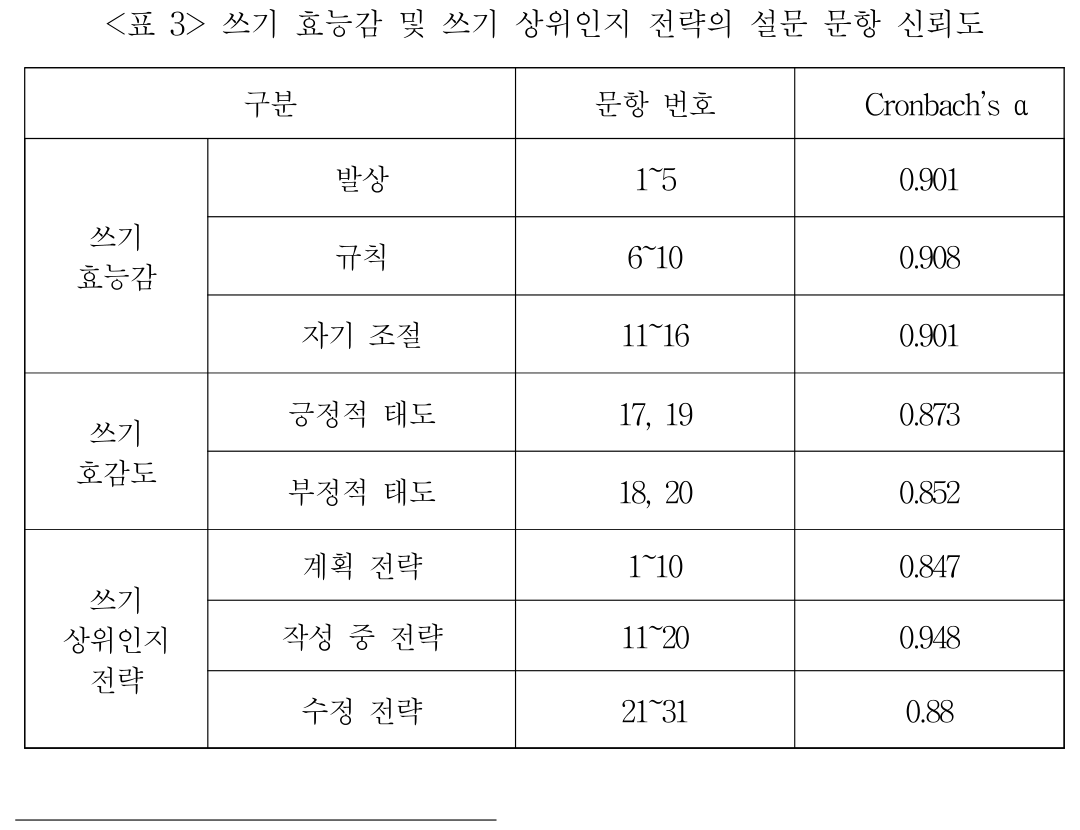

In [17]:
stan_fa = """
data {
  int<lower=1> N;
  int<lower=2> K;
  array[N] vector[K] X;           // 문항 응답
}
parameters {
  vector[K] mu;
  vector<lower=0>[K] lam;         // 요인부하량 (양수 제약)
  vector<lower=0>[K] psi;         // 문항 고유 표준편차
}
model {
  mu ~ normal(3, 2);
  lam ~ normal(0, 2);
  psi ~ normal(0, 2);
  X ~ multi_normal(mu, add_diag(lam * lam', square(psi)));   // Sigma = lam lam' + diag(psi^2)
}
generated quantities {
  real alpha;                     // Cronbach's α (Sigma 의 함수)
  real omega;                     // McDonald's ω
  {
    matrix[K, K] Sigma = add_diag(lam * lam', square(psi));
    alpha = K / (K - 1.0) * (1 - trace(Sigma) / sum(Sigma));
    omega = square(sum(lam)) / (square(sum(lam)) + sum(square(psi)));
  }
}
"""
stan_mvn = """
data {
  int<lower=1> N;
  int<lower=2> K;
  array[N] vector[K] X;           // 관측 벡터
  real<lower=0> eta;              // LKJ 형상모수 (1 = 상관행렬 위의 균일분포)
}
parameters {
  vector[K] mu;
  vector<lower=0>[K] tau;         // 표준편차
  cholesky_factor_corr[K] L;      // 상관행렬의 촐레스키 인수
}
model {
  mu ~ normal(3, 2);
  tau ~ normal(0, 2);
  L ~ lkj_corr_cholesky(eta);
  X ~ multi_normal_cholesky(mu, diag_pre_multiply(tau, L));
}
generated quantities {
  matrix[K, K] Omega = multiply_lower_tri_self_transpose(L);      // 상관행렬
  real alpha;
  {
    matrix[K, K] Sigma = quad_form_diag(Omega, tau);              // diag(tau) Omega diag(tau)
    alpha = K / (K - 1.0) * (1 - trace(Sigma) / sum(Sigma));
  }
}
"""
paper_alpha = {"발상": .901, "규칙": .908, "자기조절": .901, "긍정": .873, "부정": .852, "계획": .847, "작성": .948, "검토": .880}
post_alpha, alpha_model = {}, {}
for n, cols in SUB.items():
    K = len(cols); Xk = df[cols].to_numpy(float)
    if K >= 3:      # 1요인 측정모형
        _, post_alpha[n] = run_stan("one_factor", stan_fa, {"N": N, "K": K, "X": Xk}, inits={"mu": [3.0] * K, "lam": [0.7] * K, "psi": [0.5] * K})
        alpha_model[n] = "1요인"
    else:           # 2문항: 이변량 정규 (비구조 Σ)
        _, post_alpha[n] = run_stan("mvn_lkj", stan_mvn, {"N": N, "K": 2, "X": Xk, "eta": 1.0})
        alpha_model[n] = "이변량"

[one_factor] 표본추출 2.5s,  발산 전이 = 0


[one_factor] 표본추출 2.4s,  발산 전이 = 0


[one_factor] 표본추출 2.6s,  발산 전이 = 0


[mvn_lkj] 표본추출 1.1s,  발산 전이 = 0


[mvn_lkj] 표본추출 0.8s,  발산 전이 = 0


[one_factor] 표본추출 4.1s,  발산 전이 = 0


[one_factor] 표본추출 5.5s,  발산 전이 = 0


[one_factor] 표본추출 4.8s,  발산 전이 = 0


In [18]:
def sample_alpha(X):
    X = np.asarray(X, float); k = X.shape[1]
    return k / (k - 1) * (1 - X.var(axis=0, ddof=1).sum() / X.sum(axis=1).var(ddof=1))
rows = []
for n in names:
    a = flat(post_alpha[n], "alpha"); lo, hi = hdi(a); ch = post_alpha[n]["alpha"]
    w = flat(post_alpha[n], "omega").mean() if "omega" in post_alpha[n] else np.nan
    rows.append([len(SUB[n]), alpha_model[n], paper_alpha[n], sample_alpha(df[SUB[n]]), a.mean(), a.std(ddof=1), lo, hi, np.mean(a > .8), np.mean(a > .9),
                 w, split_rhat(ch), ess(ch)])
tab3 = pd.DataFrame(rows, index=names, columns=["k", "모형", "α(논문)", "α(표본, numpy)", "α 사후평균", "사후SD", "HDI 하한", "HDI 상한", "P(α>0.8)", "P(α>0.9)", "ω 사후평균", "R̂", "ESS"])
print(tab3.round(3).to_string())

       k   모형  α(논문)  α(표본, numpy)  α 사후평균   사후SD  HDI 하한  HDI 상한  P(α>0.8)  P(α>0.9)  ω 사후평균     R̂       ESS
발상     5  1요인  0.901         0.901   0.899  0.013   0.875   0.923     1.000     0.504   0.901  1.002  2100.950
규칙     5  1요인  0.908         0.905   0.904  0.012   0.881   0.927     1.000     0.646   0.905  1.000  1740.411
자기조절   6  1요인  0.901         0.903   0.903  0.012   0.880   0.925     1.000     0.606   0.904  1.000  1506.368
긍정     2  이변량  0.873         0.866   0.862  0.021   0.817   0.900     0.994     0.025     NaN  1.000  2248.032
부정     2  이변량  0.852         0.857   0.852  0.022   0.808   0.893     0.984     0.008     NaN  1.001  2490.518
계획    10  1요인  0.847         0.848   0.850  0.018   0.814   0.883     0.994     0.000   0.852  1.001  1511.827
작성    10  1요인  0.948         0.948   0.949  0.006   0.937   0.960     1.000     1.000   0.949  1.001  1026.147
검토    11  1요인  0.880         0.880   0.882  0.013   0.856   0.905     1.000     0.074   0.888  1.003  1459.812


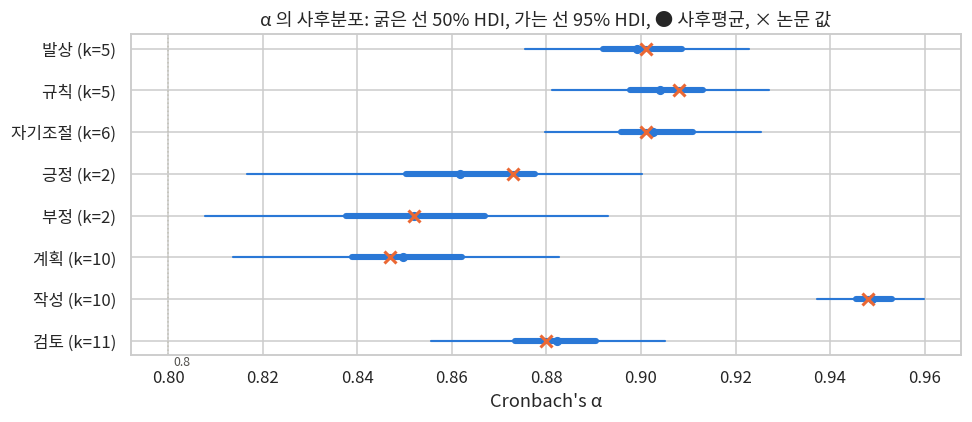

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
for i, n in enumerate(names):
    a = flat(post_alpha[n], "alpha"); lo, hi = hdi(a); lo50, hi50 = hdi(a, .5)
    ax.plot([lo, hi], [i, i], color=BLUE, lw=1.4); ax.plot([lo50, hi50], [i, i], color=BLUE, lw=4)
    ax.plot(a.mean(), i, "o", color=BLUE, ms=5); ax.plot(paper_alpha[n], i, "x", color=ORANGE, ms=8, mew=2)
ax.axvline(.8, color=GRAY, ls=":", lw=1); ax.text(.801, 7.6, "0.8", color="#52514e", fontsize=8)
ax.set(yticks=range(8), yticklabels=[f"{n} (k={len(SUB[n])})" for n in names], xlabel="Cronbach's α",
       title="α 의 사후분포: 굵은 선 50% HDI, 가는 선 95% HDI, ● 사후평균, × 논문 값")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

**베이즈 논문이라면 <표 3> 을 이렇게 쓴다**: "발상 5문항의 α 사후평균은 .90 (95 % HDI [.87, .92]) 으로 0.8 을 넘을 사후확률이 1.00 이었다(ω = .90). 문항이 2개인 긍정적 태도는 α = .87 [.81, .91] 로 구간이 넓었다." — 그림에서 2문항 척도(긍정·부정)의 95 % HDI 가 5~11문항 척도보다 두 배 이상 넓다는 것이 한눈에 보인다. 이 "**불확실성의 크기 차이**"가 베이즈 보고의 핵심 이득이다.

### 5-1. 사전분포 민감도 — "무정보" 사전분포는 없다

같은 자료(계획 전략 10문항)에 대해 $\Sigma$ 에 구조를 두지 않는 다변량 정규모형 $x_i\sim N_k(\mu,\ \operatorname{diag}(\tau)\,\Omega\,\operatorname{diag}(\tau))$, $\Omega\sim\text{LKJ}(\eta)$ 를 돌려 α 의 사후분포를 비교한다.

LKJ(η=1) 은 "모든 상관행렬이 똑같이 그럴듯하다"는 균일분포이지만, 10차원에서는 상관 하나하나의 주변분포가 $\text{Beta}(k/2, k/2)$ 꼴로 0 근처에 몰린다 — 상관이 모두 .4~.6 인 행렬은 양의 정부호 행렬 전체의 부피에서 아주 작은 구석이기 때문이다. 그래서 N=172 로도 사후평균이 표본 α 보다 눈에 띄게 낮아진다. 이것은 오류가 아니라 **"균일"이 모수화에 따라 다른 뜻이 된다**는 사실의 예시이며, 베이즈 보고에 사전분포 명세와 민감도 분석이 필수인 이유다.

In [20]:
Xp = df[SUB["계획"]].to_numpy(float)
_, post_lkj = run_stan("mvn_lkj", stan_mvn, {"N": N, "K": 10, "X": Xp, "eta": 1.0})

[mvn_lkj] 표본추출 4.4s,  발산 전이 = 0


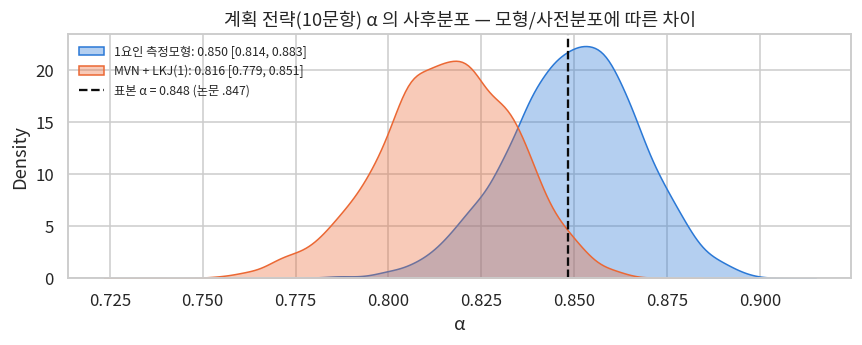

In [21]:
a_fa, a_lkj = flat(post_alpha["계획"], "alpha"), flat(post_lkj, "alpha")
fig, ax = plt.subplots(figsize=(8, 3.3))
sns.kdeplot(a_fa, ax=ax, fill=True, alpha=.35, color=BLUE, label=f"1요인 측정모형: {a_fa.mean():.3f} [{hdi(a_fa)[0]:.3f}, {hdi(a_fa)[1]:.3f}]")
sns.kdeplot(a_lkj, ax=ax, fill=True, alpha=.35, color=ORANGE, label=f"MVN + LKJ(1): {a_lkj.mean():.3f} [{hdi(a_lkj)[0]:.3f}, {hdi(a_lkj)[1]:.3f}]")
ax.axvline(sample_alpha(Xp), color=DARK, ls="--", label=f"표본 α = {sample_alpha(Xp):.3f} (논문 .847)")
ax.set(title="계획 전략(10문항) α 의 사후분포 — 모형/사전분포에 따른 차이", xlabel="α"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 6. <표 7> 상관 → 이변량 정규모형 (그리고 8변량 결합모형과의 비교)

**빈도주의 보고**: r = .858**, 별표는 "$\rho=0$ 이라는 귀무가설을 $p<.001$ 로 기각"이라는 뜻. N=172 에서는 |r|≥.25 면 모두 ** 라서 별표가 관계의 크기를 말해 주지 못한다(빈도주의 노트북 7절).

**베이즈 모형**. 피어슨 상관에 정확히 대응하는 모형은 두 변수의 **이변량 정규분포**다:

$$
\begin{pmatrix} y_{ia}\\ y_{ib}\end{pmatrix} \sim N_2\!\left(\mu,\ \begin{pmatrix}\tau_a^2 & \rho\tau_a\tau_b\\ \rho\tau_a\tau_b & \tau_b^2\end{pmatrix}\right), \qquad \rho \sim \text{Uniform}(-1, 1)\ (=\text{LKJ}(1),\ K=2)
$$

논문의 표처럼 28개 쌍 각각에 대해 이 모형을 돌리면(같은 프로그램, 자료만 교체) 각 $\rho_{ab}$ 의 사후분포를 얻는다. 2차원에서는 LKJ(1) 이 정말로 $\rho$ 에 대해 균일하므로 사후평균은 표본 r 과 거의 같고, 남는 차이는 사후분포의 비대칭(|r| 이 클수록 1 쪽이 눌려 안쪽으로 치우침) 때문이다.

- **별표 대신 사후확률**: $P(\rho_{ab}>0\mid D)$ 가 1.000 이면 논문의 ** 에 해당한다. 그러나 베이즈 보고의 초점은 "0 이 아닌가"가 아니라 "**얼마나 크고 얼마나 확실한가**"다: ".83 [.78, .87]".
- 사후 HDI 의 폭은 상관이 클수록 좁다(.83 은 ±.04, .26 은 ±.14). 상관의 표준오차가 $\approx (1-r^2)/\sqrt{N}$ 인 것과 같은 현상이다.
- **결합모형**: 8개 변수를 한 번에 다변량 정규 + LKJ(1) 로 모형화하면 상관행렬 전체의 사후표본(양의 정부호가 보장된 4000개 행렬)을 얻어 "두 상관의 차이" 같은 결합 질문에 답할 수 있다. 다만 5-1 절에서 본 대로 8차원 LKJ(1) 은 상관을 0 쪽으로 .03 정도 당긴다. 두 결과를 나란히 놓고 이 차이를 확인한다.

**논문 원문 캡처** — <표 7> 쓰기 효능감과 쓰기 상위인지 전략 간의 상관관계

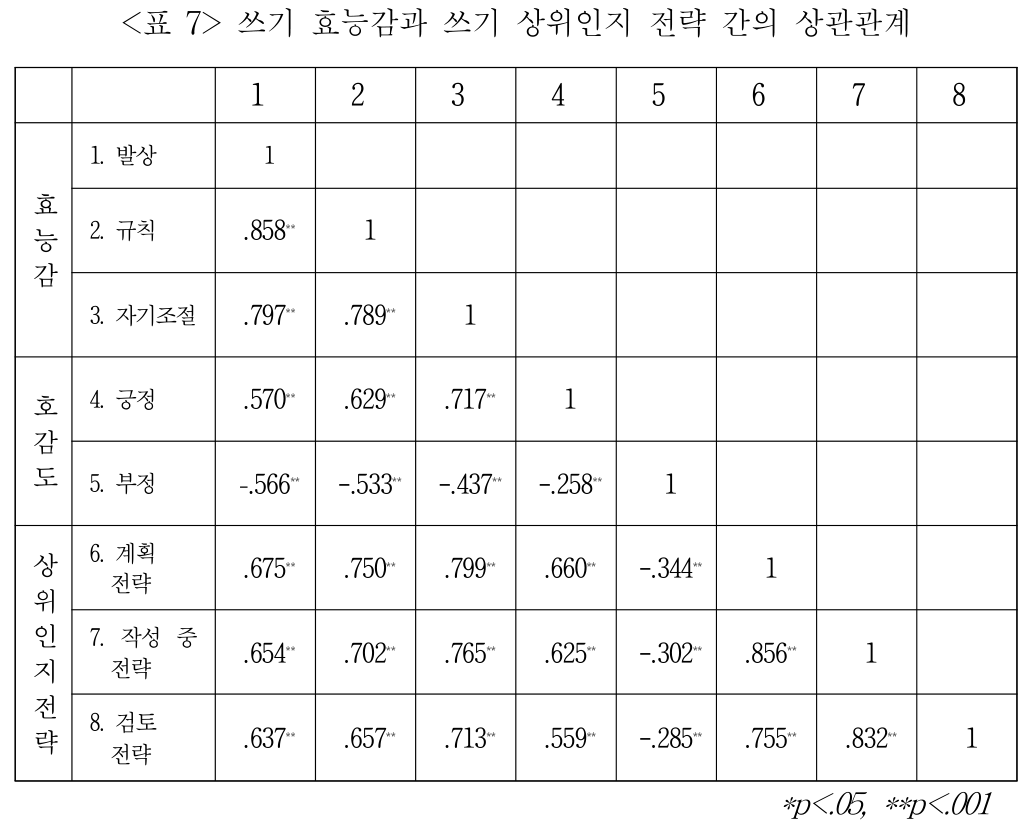

In [22]:
pairs = [(a, b) for a in range(8) for b in range(a + 1, 8)]        # 28 쌍
rho_pair = {}
import contextlib, io
t0 = time.time()
for (a, b) in pairs:
    with contextlib.redirect_stdout(io.StringIO()):                  # 출력 없이 조용히 28회 실행
        _, p_ = run_stan("mvn_lkj", stan_mvn, {"N": N, "K": 2, "X": S[:, [a, b]], "eta": 1.0})
    rho_pair[(a, b)] = flat(p_, "Omega")[:, 0, 1]
print(f"28개 이변량 모형 표본추출 완료: {time.time()-t0:.0f}s")
# 결합 8변량 모형
_, post_corr = run_stan("mvn_lkj", stan_mvn, {"N": N, "K": 8, "X": S, "eta": 1.0})

28개 이변량 모형 표본추출 완료: 23s


[mvn_lkj] 표본추출 4.6s,  발산 전이 = 0


In [23]:
paper7 = np.array([
    [1.000, 0.858, 0.797, 0.570, -0.566, 0.675, 0.654, 0.637],
    [0.858, 1.000, 0.789, 0.629, -0.533, 0.750, 0.702, 0.657],
    [0.797, 0.789, 1.000, 0.717, -0.437, 0.799, 0.765, 0.713],
    [0.570, 0.629, 0.717, 1.000, -0.258, 0.660, 0.625, 0.559],
    [-0.566, -0.533, -0.437, -0.258, 1.000, -0.344, -0.302, -0.285],
    [0.675, 0.750, 0.799, 0.660, -0.344, 1.000, 0.856, 0.755],
    [0.654, 0.702, 0.765, 0.625, -0.302, 0.856, 1.000, 0.832],
    [0.637, 0.657, 0.713, 0.559, -0.285, 0.755, 0.832, 1.000],
])
R_sample = np.corrcoef(S.T)
R_mean = np.eye(8); R_lo = np.eye(8); R_hi = np.eye(8); P_pos = np.ones((8, 8))
for (a, b), r in rho_pair.items():
    R_mean[a, b] = R_mean[b, a] = r.mean(); R_lo[a, b], R_hi[a, b] = hdi(r); R_lo[b, a], R_hi[b, a] = R_lo[a, b], R_hi[a, b]
    P_pos[a, b] = P_pos[b, a] = np.mean(r > 0)
Om = flat(post_corr, "Omega"); Om_mean = Om.mean(axis=0)

print("하삼각: 이변량 모형 사후평균 [95% HDI]  P(ρ>0)  /  논문 r\n")
for a in range(8):
    line = f"{a+1}. {names[a]:<5s}"
    for b in range(a):
        line += f" {R_mean[a,b]:+.3f} [{R_lo[a,b]:+.2f},{R_hi[a,b]:+.2f}] p+={P_pos[a,b]:.3f} /{paper7[a,b]:+.3f} |"
    print(line)
iu = np.triu_indices(8, 1)
print(f"\n이변량 사후평균 vs 표본 r : 최대 절대 차이 {np.abs(R_mean[iu]-R_sample[iu]).max():.3f}")
print(f"이변량 사후평균 vs 논문 r : 최대 절대 오차 {np.abs(R_mean[iu]-paper7[iu]).max():.3f}, 평균 {np.abs(R_mean[iu]-paper7[iu]).mean():.3f}")
print(f"8변량 결합모형 사후평균 vs 표본 r : 평균 차이 {np.mean(Om_mean[iu]-R_sample[iu]):+.3f}  (LKJ(1) 의 0 쪽 축소)")
print("모든 쌍에서 max(P(ρ>0), P(ρ<0)) ≥ 0.999 인가?", bool((np.maximum(P_pos[iu], 1-P_pos[iu]) >= .999).all()), " (논문의 ** 에 해당)")

하삼각: 이변량 모형 사후평균 [95% HDI]  P(ρ>0)  /  논문 r

1. 발상   
2. 규칙    +0.836 [+0.79,+0.88] p+=1.000 /+0.858 |
3. 자기조절  +0.782 [+0.72,+0.84] p+=1.000 /+0.797 | +0.783 [+0.72,+0.84] p+=1.000 /+0.789 |
4. 긍정    +0.559 [+0.46,+0.66] p+=1.000 /+0.570 | +0.623 [+0.53,+0.72] p+=1.000 /+0.629 | +0.708 [+0.63,+0.78] p+=1.000 /+0.717 |
5. 부정    -0.560 [-0.66,-0.45] p+=0.000 /-0.566 | -0.524 [-0.63,-0.42] p+=0.000 /-0.533 | -0.434 [-0.55,-0.31] p+=0.000 /-0.437 | -0.253 [-0.39,-0.12] p+=0.000 /-0.258 |
6. 계획    +0.669 [+0.59,+0.75] p+=1.000 /+0.675 | +0.725 [+0.65,+0.79] p+=1.000 /+0.750 | +0.780 [+0.72,+0.83] p+=1.000 /+0.799 | +0.652 [+0.56,+0.73] p+=1.000 /+0.660 | -0.340 [-0.46,-0.20] p+=0.000 /-0.344 |
7. 작성    +0.638 [+0.54,+0.73] p+=1.000 /+0.654 | +0.698 [+0.62,+0.77] p+=1.000 /+0.702 | +0.760 [+0.69,+0.83] p+=1.000 /+0.765 | +0.620 [+0.53,+0.71] p+=1.000 /+0.625 | -0.304 [-0.43,-0.17] p+=0.000 /-0.302 | +0.838 [+0.79,+0.88] p+=1.000 /+0.856 |
8. 검토    +0.621 [+0.53,+0.71] p+=1.000 /+0.637 | +0.

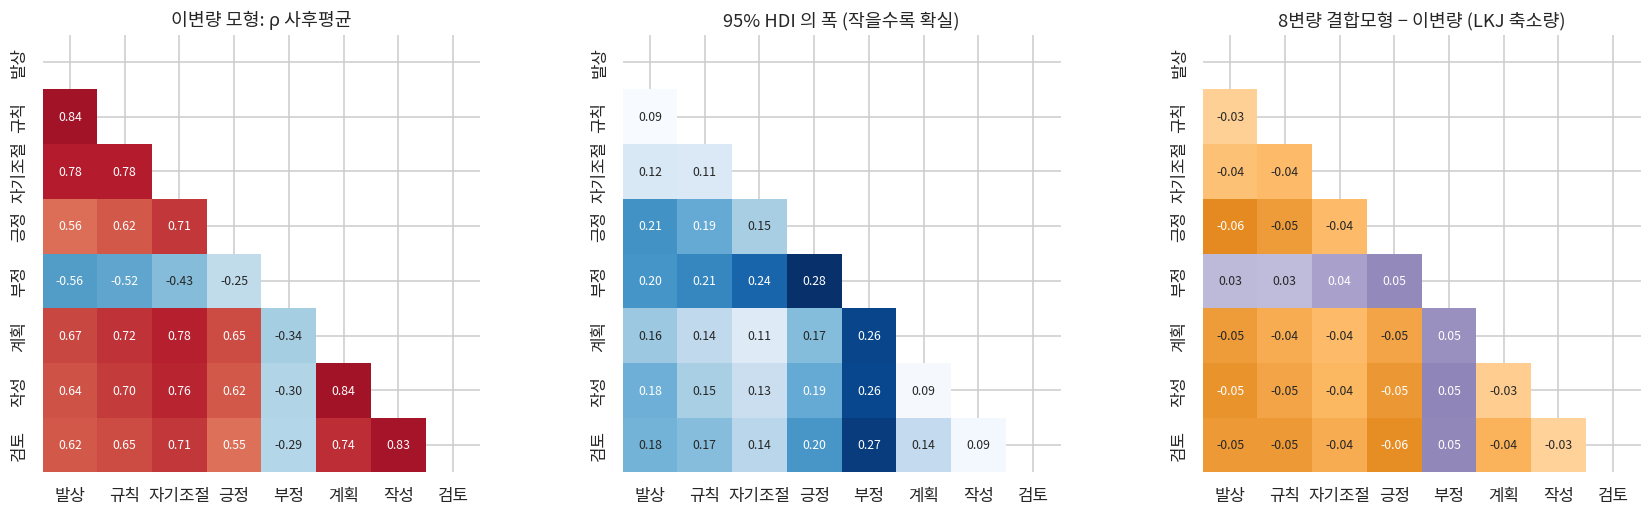

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
mask = np.triu(np.ones((8, 8), bool))
sns.heatmap(R_mean, mask=mask, ax=axes[0], cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, xticklabels=names, yticklabels=names, cbar=False, square=True)
axes[0].set_title("이변량 모형: ρ 사후평균")
sns.heatmap(R_hi - R_lo, mask=mask, ax=axes[1], cmap="Blues", annot=True, fmt=".2f", annot_kws={"size": 8}, xticklabels=names, yticklabels=names, cbar=False, square=True)
axes[1].set_title("95% HDI 의 폭 (작을수록 확실)")
sns.heatmap(Om_mean - R_mean, mask=mask, ax=axes[2], cmap="PuOr", vmin=-.1, vmax=.1, annot=True, fmt=".2f", annot_kws={"size": 8}, xticklabels=names, yticklabels=names, cbar=False, square=True)
axes[2].set_title("8변량 결합모형 − 이변량 (LKJ 축소량)")
plt.tight_layout(); plt.show()

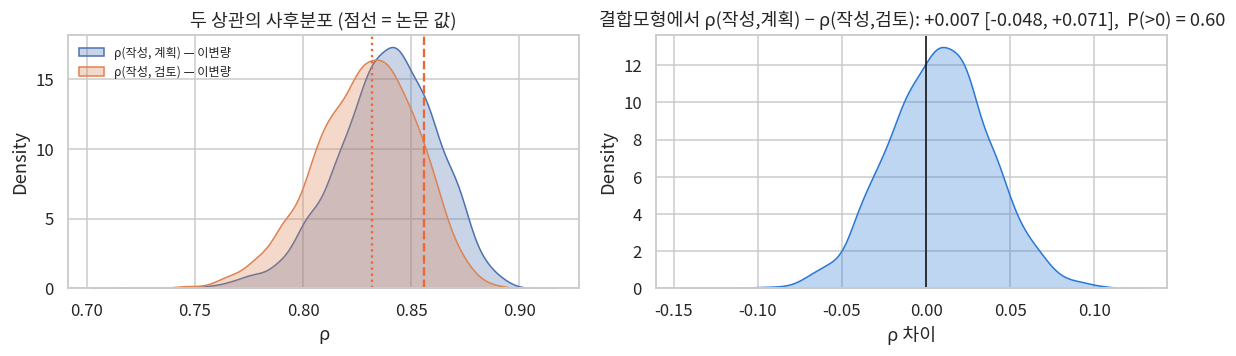

In [25]:
# 결합모형의 쓸모: 상관 두 개를 직접 비교 — 작성-계획 (.856) vs 작성-검토 (.832)
i_w, i_p, i_r = names.index("작성"), names.index("계획"), names.index("검토")
d = Om[:, i_w, i_p] - Om[:, i_w, i_r]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.kdeplot(rho_pair[(min(i_w,i_p), max(i_w,i_p))], ax=axes[0], fill=True, alpha=.3, label="ρ(작성, 계획) — 이변량")
sns.kdeplot(rho_pair[(min(i_w,i_r), max(i_w,i_r))], ax=axes[0], fill=True, alpha=.3, label="ρ(작성, 검토) — 이변량")
axes[0].axvline(paper7[i_w, i_p], color=ORANGE, ls="--"); axes[0].axvline(paper7[i_w, i_r], color=ORANGE, ls=":")
axes[0].set(title="두 상관의 사후분포 (점선 = 논문 값)", xlabel="ρ"); axes[0].legend(frameon=False, fontsize=8)
sns.kdeplot(d, ax=axes[1], fill=True, color=BLUE, alpha=.3); axes[1].axvline(0, color=DARK, lw=1)
lo, hi = hdi(d)
axes[1].set(title=f"결합모형에서 ρ(작성,계획) − ρ(작성,검토): {d.mean():+.3f} [{lo:+.3f}, {hi:+.3f}],  P(>0) = {np.mean(d>0):.2f}", xlabel="ρ 차이")
plt.tight_layout(); plt.show()

**베이즈 논문이라면 <표 7> 을 이렇게 쓴다**: 표의 각 칸에 "사후평균 [95 % HDI]" 를 적고 별표는 뺀다(모든 $P(\rho\ne0)$ 가 .999 이상임을 각주 한 줄로). 본문의 "가장 높은 상관" 같은 순위 주장에는 결합모형에서 계산한 차이의 사후확률을 붙인다. 위 예에서 작성–계획이 작성–검토보다 큰 사후확률이 1 에 가깝지 않다면, 논문의 "가장 높은 상관" 이라는 서술은 표본 우연의 범위 안에 있다는 뜻이다. 그리고 방법 절에 "상관은 쌍별 이변량 정규모형으로 추정했고, 결합 질문에는 8변량 LKJ(1) 모형을 사용했으며 후자는 상관을 평균 .03 축소한다"고 사전분포의 영향을 밝힌다.

## 7. <표 8>·<표 9> 한국어 수준별 비교 → 집단 평균 모형

**빈도주의 보고**: 부정적 호감도 $F(2,117)=14.918$, $p<.001$, Scheffé "초·중급 < 고급". 나머지 요인은 "$p>.05$ 이므로 차이 없음". 이 절차는 (1) "세 집단 평균이 모두 같다"는 귀무가설을 F 로 검정하고, (2) 유의하면 사후검정으로 쌍을 찾는 2단계이며, (3) "유의하지 않음"을 "차이 없음"으로 읽기 쉽다는 문제가 있다.

**베이즈 모형**. TOPIK 급수가 있는 120명에 대해 집단 $g\in\{초,중,고\}$ 마다 평균과 표준편차를 둔다.

$$
y_{i s} \sim N(\mu_{g(i), s},\ \sigma_{g(i), s}), \qquad \mu_{gs}\sim N(3,2), \qquad \sigma_{gs}\sim N^+(0,2)
$$

관심 있는 양은 집단 **평균 차이** $\delta = \mu_{고} - \mu_{초}$ 등 세 쌍이다. 사후표본에서 $\mu$ 들을 빼기만 하면 $\delta$ 의 사후분포가 나온다.

- **F 검정 → 차이의 추정**: "차이가 있는가"(예/아니오)가 아니라 "차이가 얼마이고 얼마나 확실한가"를 답한다: $\delta \approx 1.2$ [0.75, 1.7], $P(\delta>0)=1.000$.
- **Scheffé → 사후확률 표**: 모든 쌍에 대해 $P(\delta>0)$ 를 적으면 사후검정 표가 된다. 다중비교 보정이 따로 필요 없는 이유는 각 확률이 "그 쌍의 차이에 대한 사후 믿음"이지 오류율이 아니기 때문이다(단, 많은 비교 중 큰 것만 골라 보고하는 관행 자체는 여전히 경계해야 하며, 그 해법은 계층모형의 축소(shrinkage)다).
- **"차이 없음"을 말하는 법 — ROPE**: 실질적으로 무시할 만한 차이의 범위(예: 5점 척도에서 ±0.1점)를 미리 정하고, $\delta$ 가 그 안에 있을 사후확률을 본다. $p>.05$ 는 "차이 없음"의 근거가 못 되지만, "$P(|\delta|<0.1)=0.85$" 는 근거가 된다.
- **효과크기**: $d = \delta/\sigma_{pooled}$ 의 사후분포로 Cohen's d 에 해당하는 값과 그 불확실성을 함께 보고한다.

> 시뮬레이션 자료와 논문 표의 관계(빈도주의 노트북 8절과 동일): 급수별 M·SD 는 여섯 요인에서 논문과 일치하지만, 긍정 호감도와 검토 전략은 논문의 급수별 M·SD 가 <표 5> 와 산술적으로 양립하지 않아 기본 데이터에서는 집단 차이를 35 % 로 축소했다. `survey_data_table89.csv`(`--priority table89`) 를 대신 읽으면 이 두 요인이 논문의 표 8·9 쪽에 맞춰진다.

**논문 원문 캡처** — <표 8> 한국어 수준에 따른 쓰기 효능감, 호감도 결과

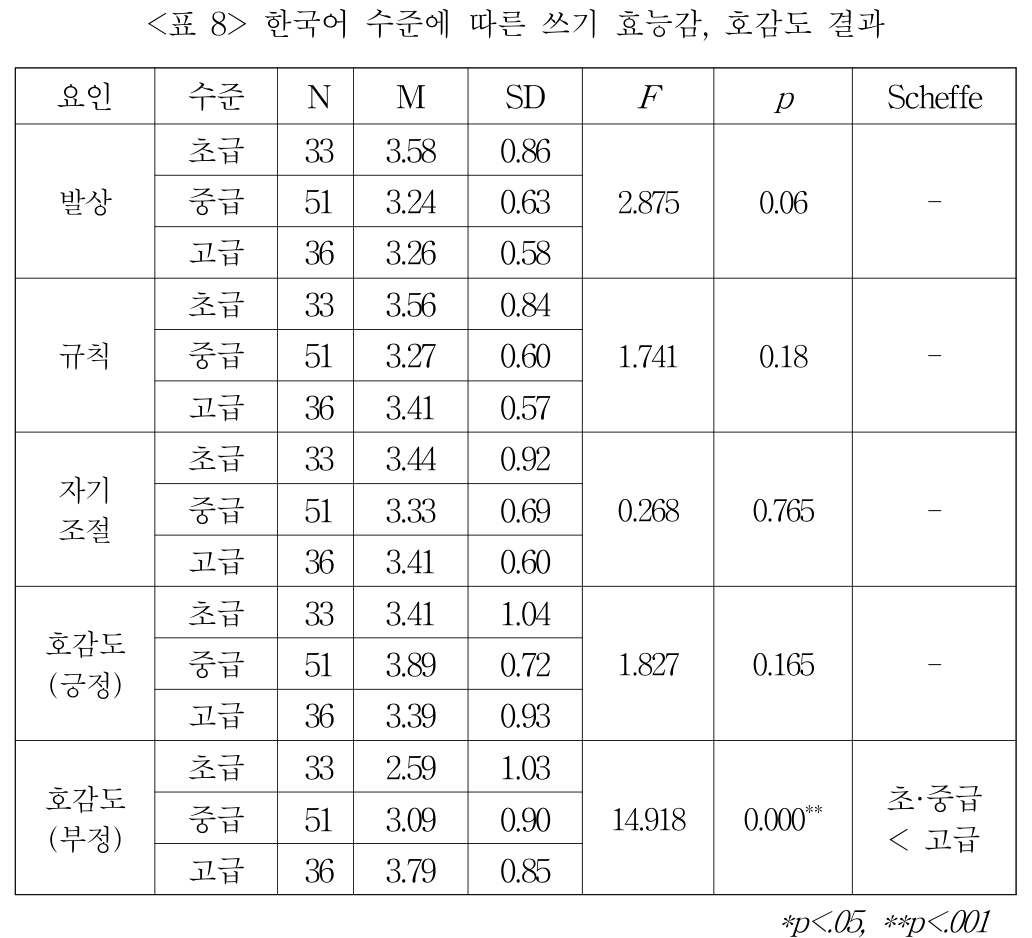

(<표 9> 도 같은 절차)

**논문 원문 캡처** — <표 9> 한국어 수준에 따른 쓰기 상위인지 전략 결과

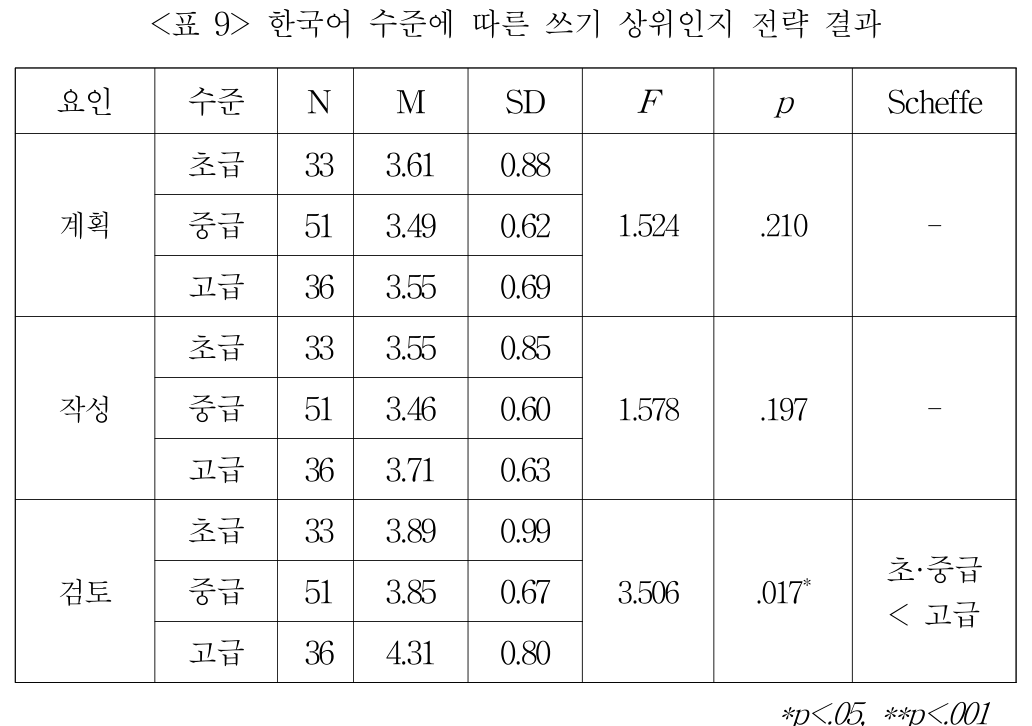

In [26]:
stan_groups = """
data {
  int<lower=1> N;
  int<lower=1> S;
  int<lower=2> G;
  matrix[N, S] y;
  array[N] int<lower=1, upper=G> g;     // 집단 지표 (1=초급, 2=중급, 3=고급)
}
parameters {
  matrix[G, S] mu;
  matrix<lower=0>[G, S] sigma;
}
model {
  to_vector(mu) ~ normal(3, 2);
  to_vector(sigma) ~ normal(0, 2);
  for (s in 1:S) y[:, s] ~ normal(mu[g, s], sigma[g, s]);   // mu[g, s]: 관측별 소속 집단의 평균
}
"""
mask = df["topik"].to_numpy() > 0
g_idx = df["topik"].to_numpy()[mask]                       # 1, 2, 3
_, post_grp = run_stan("groups", stan_groups, {"N": int(mask.sum()), "S": 8, "G": 3, "y": S[mask], "g": g_idx.tolist()})

[groups] 표본추출 1.7s,  발산 전이 = 0


In [27]:
paper89 = {"발상": (2.875, .060, "-"), "규칙": (1.741, .180, "-"), "자기조절": (0.268, .765, "-"), "긍정": (1.827, .165, "-"),
           "부정": (14.918, .000, "초·중급<고급"), "계획": (1.524, .210, "-"), "작성": (1.578, .197, "-"), "검토": (3.506, .017, "초·중급<고급")}
lv = ["초급", "중급", "고급"]
mu_g = flat(post_grp, "mu"); sg_g = flat(post_grp, "sigma")          # (4000, 3, 8)
ROPE = 0.1
rows = []
for s, n in enumerate(names):
    for (a, b) in [(0, 2), (1, 2), (0, 1)]:                          # 고-초, 고-중, 중-초
        d = mu_g[:, b, s] - mu_g[:, a, s]
        sp = np.sqrt((sg_g[:, a, s] ** 2 + sg_g[:, b, s] ** 2) / 2)
        lo, hi = hdi(d)
        rows.append([n, f"{lv[b]}−{lv[a]}", d.mean(), lo, hi, np.mean(d > 0), np.mean(np.abs(d) < ROPE), (d / sp).mean(),
                     paper89[n][0] if (a, b) == (0, 2) else "", paper89[n][1] if (a, b) == (0, 2) else "", paper89[n][2] if (a, b) == (0, 2) else ""])
tab89 = pd.DataFrame(rows, columns=["요인", "차이 δ", "사후평균", "HDI 하한", "HDI 상한", "P(δ>0)", f"P(|δ|<{ROPE})", "효과크기 d", "F(논문)", "p(논문)", "Scheffé(논문)"])
print(tab89.round(3).to_string(index=False))
print("\nR̂ 최대 =", round(max(split_rhat(post_grp['mu'][:, :, i, j]) for i in range(3) for j in range(8)), 3),
      " ESS 최소 =", round(min(ess(post_grp['mu'][:, :, i, j]) for i in range(3) for j in range(8))))

  요인  차이 δ   사후평균  HDI 하한  HDI 상한  P(δ>0)  P(|δ|<0.1)  효과크기 d   F(논문)  p(논문) Scheffé(논문)
  발상 고급−초급 -0.318  -0.681   0.066   0.052       0.103  -0.416   2.875   0.06           -
  발상 고급−중급  0.026  -0.224   0.314   0.574       0.513   0.042                           
  발상 중급−초급 -0.344  -0.710   0.013   0.031       0.086  -0.442                           
  규칙 고급−초급 -0.145  -0.477   0.213   0.204       0.328  -0.197   1.741   0.18           -
  규칙 고급−중급  0.153  -0.112   0.402   0.886       0.309   0.259                           
  규칙 중급−초급 -0.298  -0.631   0.020   0.036       0.112  -0.401                           
자기조절 고급−초급 -0.028  -0.411   0.338   0.441       0.374  -0.035   0.268  0.765           -
자기조절 고급−중급  0.076  -0.192   0.363   0.702       0.465   0.114                           
자기조절 중급−초급 -0.104  -0.485   0.257   0.292       0.346  -0.124                           
  긍정 고급−초급  0.016  -0.432   0.489   0.525       0.338   0.017   1.827  0.165           -
  긍정 고급−중급 -0.174  -0

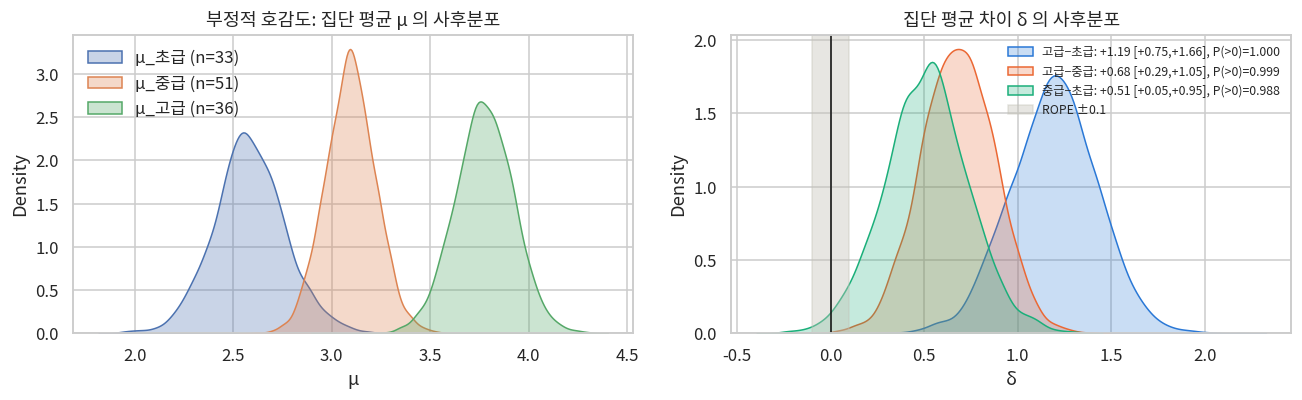

In [28]:
# 부정적 호감도: 세 집단 평균의 사후분포와 차이의 사후분포
s = names.index("부정")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for gi, lab in enumerate(lv):
    sns.kdeplot(mu_g[:, gi, s], ax=axes[0], fill=True, alpha=.3, label=f"μ_{lab} (n={np.sum(g_idx == (gi if g_idx.min()==0 else gi+1))})")
axes[0].set(title="부정적 호감도: 집단 평균 μ 의 사후분포", xlabel="μ"); axes[0].legend(frameon=False)
for (a, b), col in zip([(0, 2), (1, 2), (0, 1)], [BLUE, ORANGE, "#1baf7a"]):
    d = mu_g[:, b, s] - mu_g[:, a, s]; lo, hi = hdi(d)
    sns.kdeplot(d, ax=axes[1], color=col, fill=True, alpha=.25, label=f"{lv[b]}−{lv[a]}: {d.mean():+.2f} [{lo:+.2f},{hi:+.2f}], P(>0)={np.mean(d>0):.3f}")
axes[1].axvspan(-ROPE, ROPE, color=GRAY, alpha=.4, label=f"ROPE ±{ROPE}"); axes[1].axvline(0, color=DARK, lw=1)
axes[1].set(title="집단 평균 차이 δ 의 사후분포", xlabel="δ"); axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### 7-1. 여덟 요인 × 세 집단 — 실제로 확인해야 할 여덟 장의 그림

논문 <표 8>·<표 9> 의 각 행(요인)에 대응하는 그림이다. 패널마다 세 집단의 **모평균 μ 의 사후분포**(진한 곡선, 음영 = 95 % HDI)를 그리고, 그 뒤에 **개인 점수의 분포**(옅은 곡선)를 겹쳐 두었다. 두 종류의 곡선을 같은 축에 놓기 위해 각 곡선의 높이를 최댓값 1 로 정규화했다(높이는 밀도가 아니라 상대적 모양만 뜻한다).

읽는 법 세 가지.

1. **세 진한 곡선이 겹치는가.** 거의 겹치지 않으면(부정적 호감도) 어느 쌍의 $P(\delta>0)$ 도 1 에 가깝고, 포개져 있으면(자기조절) 모든 쌍의 HDI 가 0 을 넉넉히 포함한다. 겹침의 정도가 곧 다음 forest plot 에서 HDI 가 0 을 걸치는지와 같은 정보다.
2. **곡선의 폭이 집단마다 다른가.** 사후 SD 는 대략 $\sigma/\sqrt{n}$ 이므로 중급(51명)의 곡선이 초급(33명)·고급(36명)보다 좁다. 같은 평균 차이라도 표본이 작은 쌍은 덜 확실하다.
3. **진한 곡선과 옅은 곡선의 폭 차이.** 진한 곡선은 "평균이 어디인가"에 대한 불확실성이고 옅은 곡선은 "학생들이 어떻게 퍼져 있는가"다. 부정적 호감도에서 세 진한 곡선이 완전히 갈라져 있어도 옅은 곡선들은 크게 겹친다 — "고급의 평균이 초급보다 높다는 것이 거의 확실하다"와 "고급 학생 대부분이 초급 학생 대부분보다 높다"는 다른 말이며, 후자의 정도를 재는 것이 효과크기 $d$ 다.

패널 제목에는 고급−초급 차이의 사후평균과 $P(\delta>0)$, 그리고 논문의 $F$·$p$ 를 나란히 적었다.

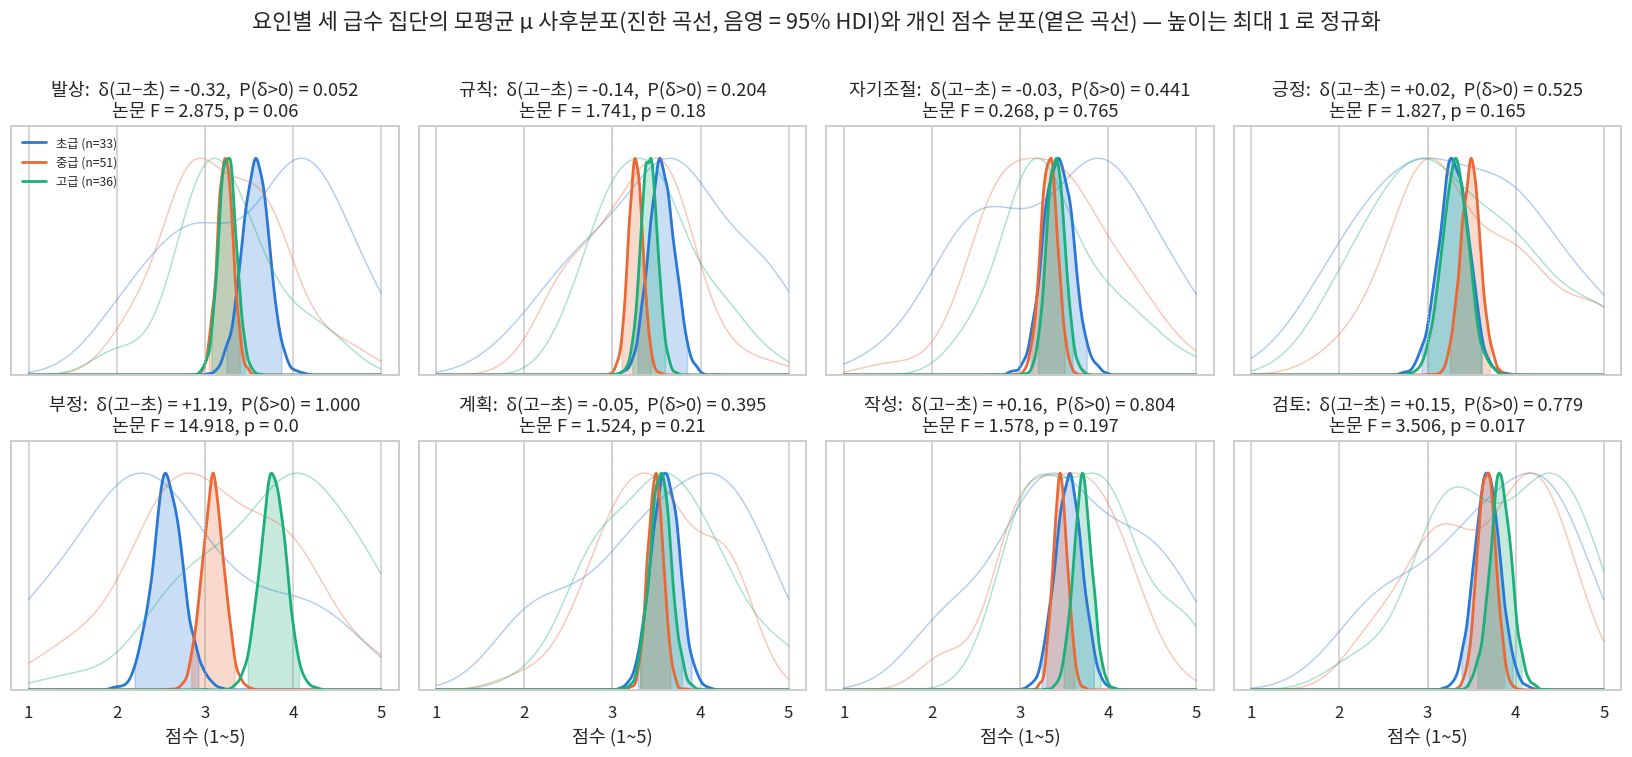

In [29]:
from scipy.stats import gaussian_kde
gcol = {0: BLUE, 1: ORANGE, 2: "#1baf7a"}
xs = np.linspace(1, 5, 400)
fig, axes = plt.subplots(2, 4, figsize=(15, 6.8), sharex=True)
for s, (ax, n) in enumerate(zip(axes.ravel(), names)):
    for gi, lab in enumerate(lv):
        raw = S[mask, s][g_idx == (gi if g_idx.min() == 0 else gi + 1)]           # 그 집단 학생들의 실제 점수
        k_raw = gaussian_kde(raw)(xs); ax.plot(xs, k_raw / k_raw.max(), color=gcol[gi], lw=1, alpha=.35)
        post = mu_g[:, gi, s]; k_mu = gaussian_kde(post)(xs); k_mu /= k_mu.max()
        ax.plot(xs, k_mu, color=gcol[gi], lw=1.8, label=f"{lab} (n={len(raw)})")
        lo, hi = hdi(post); sel = (xs >= lo) & (xs <= hi)
        ax.fill_between(xs[sel], 0, k_mu[sel], color=gcol[gi], alpha=.25)
    d = mu_g[:, 2, s] - mu_g[:, 0, s]
    ax.set(title=f"{n}:  δ(고−초) = {d.mean():+.2f},  P(δ>0) = {np.mean(d > 0):.3f}\n논문 F = {paper89[n][0]}, p = {paper89[n][1]}", ylim=(0, 1.15), yticks=[])
    ax.axvline(3, color=GRAY, lw=.8, ls=":")
    if s == 0: ax.legend(frameon=False, fontsize=8, loc="upper left")
for ax in axes[1]: ax.set_xlabel("점수 (1~5)")
plt.suptitle("요인별 세 급수 집단의 모평균 μ 사후분포(진한 곡선, 음영 = 95% HDI)와 개인 점수 분포(옅은 곡선) — 높이는 최대 1 로 정규화", y=1.01)
plt.tight_layout(); plt.show()

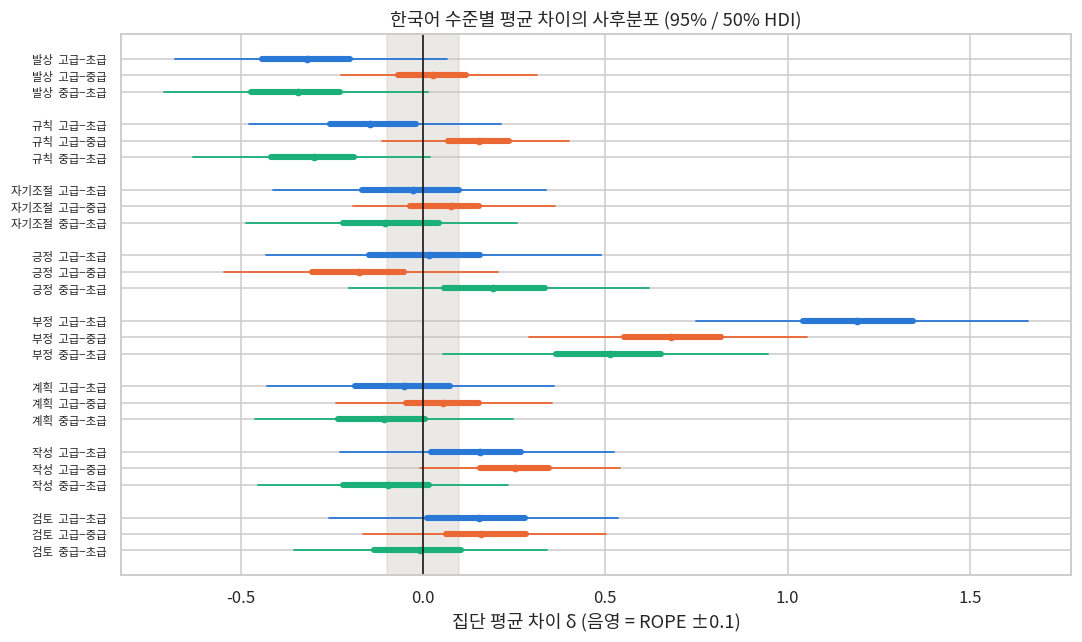

In [30]:
# 8개 요인 × 3쌍의 차이를 한 그림에 (논문의 F/p/Scheffé 표에 대응)
fig, ax = plt.subplots(figsize=(10, 6))
ytick, ylab = [], []
for s, n in enumerate(names):
    for k, ((a, b), col) in enumerate(zip([(0, 2), (1, 2), (0, 1)], [BLUE, ORANGE, "#1baf7a"])):
        d = mu_g[:, b, s] - mu_g[:, a, s]; lo, hi = hdi(d); lo50, hi50 = hdi(d, .5); y = s * 4 + k
        ax.plot([lo, hi], [y, y], color=col, lw=1.2); ax.plot([lo50, hi50], [y, y], color=col, lw=4); ax.plot(d.mean(), y, "o", color=col, ms=4)
        ytick.append(y); ylab.append(f"{n}  {lv[b]}−{lv[a]}")
ax.axvspan(-ROPE, ROPE, color=GRAY, alpha=.35); ax.axvline(0, color=DARK, lw=1)
ax.set(yticks=ytick, yticklabels=ylab, xlabel="집단 평균 차이 δ (음영 = ROPE ±0.1)", title="한국어 수준별 평균 차이의 사후분포 (95% / 50% HDI)")
ax.tick_params(axis="y", labelsize=7.5); ax.invert_yaxis(); plt.tight_layout(); plt.show()

**베이즈 논문이라면 <표 8>·<표 9> 를 이렇게 쓴다**: 요인마다 세 집단의 $\mu$ 사후평균 [HDI] 을 적은 뒤, F 와 p 열 대신 "고급−초급 $\delta$ = 1.19 [0.75, 1.66], $P(\delta>0)>.999$, $d\approx1.2$" 처럼 **차이·구간·확률·효과크기**를 적는다. 유의하지 않았던 요인에는 "자기조절: 고급−초급 $\delta=-0.03$ [−0.41, 0.34], $P(|\delta|<0.1)=0.37$" 처럼 써서 "차이가 작다는 근거가 어느 정도인지"를 밝힌다 — $p=.765$ 한 줄보다 훨씬 많은 정보다. 그림(forest plot)은 표 대신 본문에 넣는 것이 관례다.

또 하나: 빈도주의 노트북에서 초급–중급 차이는 Scheffé 임계값에 "걸릴락 말락" 했다. 위 표에서는 그 쌍의 $P(\delta>0)$ 와 HDI 를 그대로 보고하면 되며, 유의/비유의의 이분법으로 결론이 뒤집히는 일이 없다.

## 8. <표 10> 다중회귀 → 베이즈 회귀와 사전분포에 의한 정칙화

**빈도주의 보고**: 계수 B, 표준오차, β, t, p, VIF, 그리고 F, R², adj R², D–W. 논문 표의 종속변수 정의가 불명확하므로(빈도주의 노트북 9절), 여기서도 "어렵다고 고른 과제 유형 수"(0~5)를 종속변수로 두고 **절차와 보고 방식**을 대응시킨다.

**베이즈 모형** (독립변수는 평균 중심화):

$$
y_i \sim N(a + x_i^\top b,\ \sigma), \qquad a \sim N(0, 5), \qquad b_j \sim N(0, s_b), \qquad \sigma \sim N^+(0,2)
$$

| 빈도주의 | 베이즈 | 비고 |
|---|---|---|
| $\hat B$, S.E. | $b$ 의 사후평균, 사후SD | $s_b$ 가 크면(약한 사전분포) OLS 와 거의 같다 |
| $\beta$ | $b_j\,s_{x_j}/s_y$ 를 사후표본마다 계산 | 표준화 계수의 사후분포 |
| $t$, $p$ | $P(b_j>0\mid D)$ | "효과가 양일 확률" |
| $R^2$ | 베이즈 $R^2 = \dfrac{\operatorname{Var}(\hat y)}{\operatorname{Var}(\hat y)+\sigma^2}$ 의 사후분포 (Gelman et al., 2019) | 점이 아니라 분포 |
| VIF | 계수들의 **사후 상관** | 공선성이 크면 $b_{발상}$ 과 $b_{규칙}$ 의 사후표본이 강하게 음의 상관 |
| D–W | (직접 대응 없음) 사후예측검사 | 잔차 구조를 예측분포로 점검 |

**사전분포가 실제로 일하는 곳 — 다중공선성**. 발상·규칙·자기조절은 서로 r ≈ .8 이라 OLS 는 "누구의 공인지" 가리지 못해 계수가 크게 흔들리고 부호가 튄다(논문의 발상 −.441 vs 규칙 +.531). 베이즈에서 $b_j\sim N(0, s_b)$ 의 $s_b$ 를 줄이면 계수를 0 쪽으로 부드럽게 당기는 **정칙화(ridge 회귀와 같은 효과)** 가 되어 흔들림이 줄어든다. 아래에서 $s_b=1$ (약한 정보) 과 $s_b=0.2$ (정보 있음) 두 가지를 돌려 비교한다. 사전분포는 "주관"이 아니라 **"5점 척도 점수 1점 차이가 종속변수를 몇 점이나 바꿀 수 있는가"에 대한 명시적 가정**이며, 논문에 반드시 적어야 한다.

**논문 원문 캡처** — <표 10> 학습자가 어려움을 느끼는 쓰기 과제에 쓰기 효능감, 쓰기 상위인지가 미치는 영향

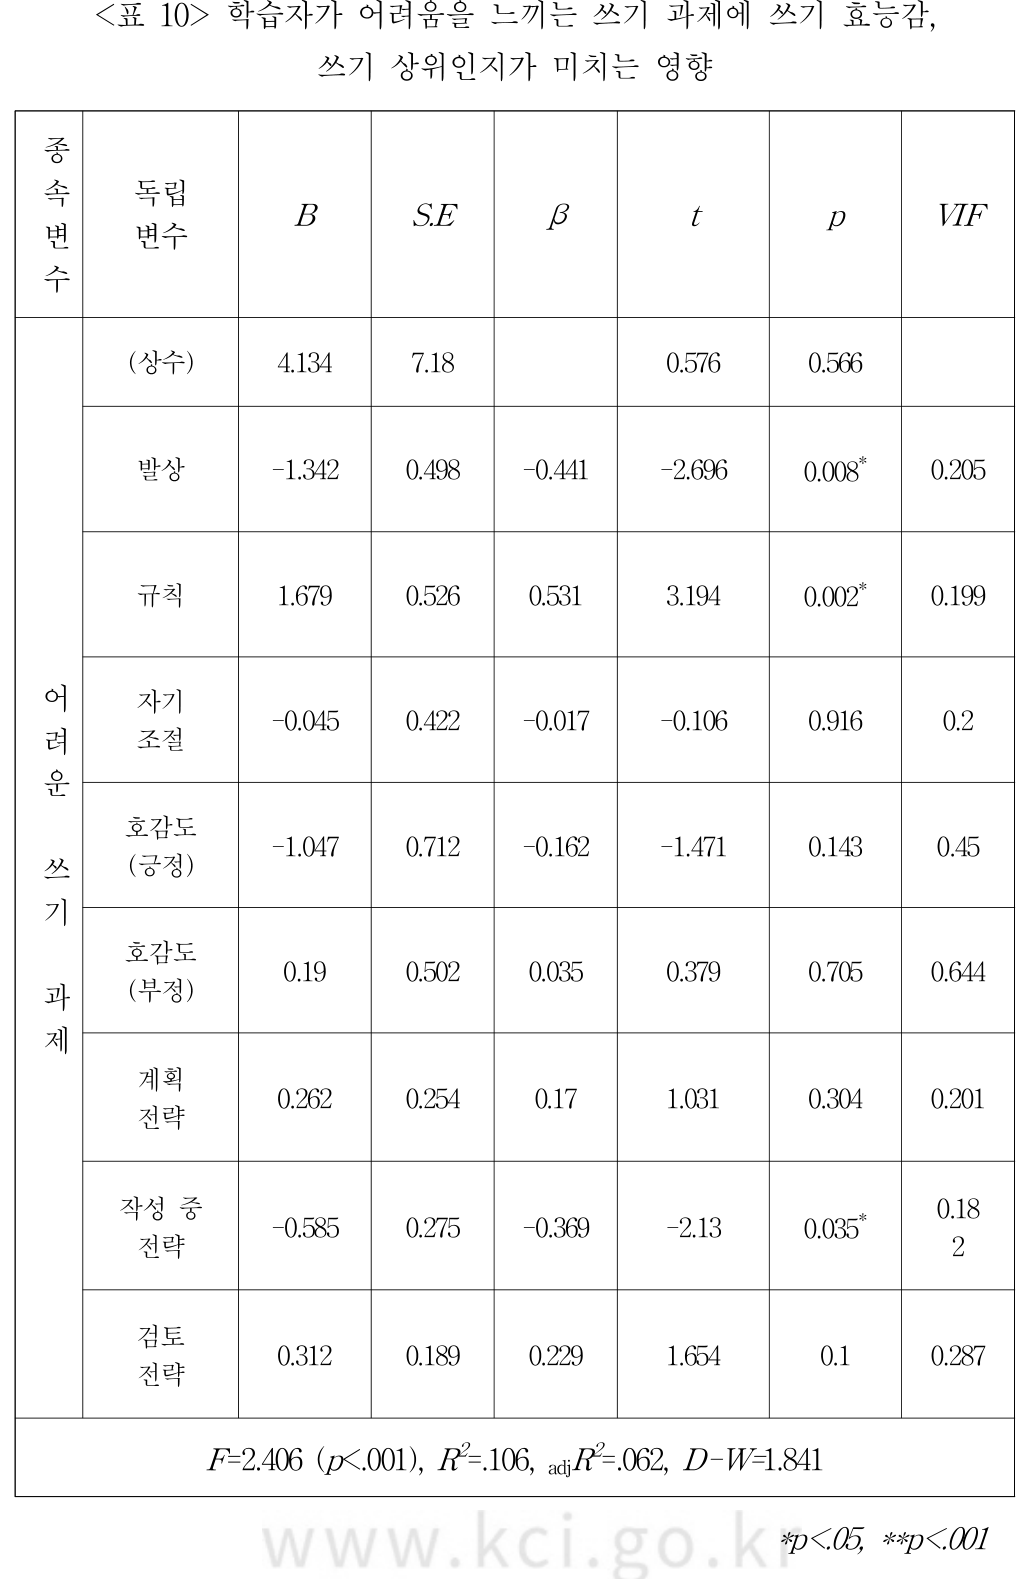

In [31]:
stan_reg = """
data {
  int<lower=1> N;
  int<lower=1> P;
  matrix[N, P] X;                 // 평균 중심화한 독립변수
  vector[N] y;
  real<lower=0> prior_sd;         // 회귀계수 사전분포의 표준편차
}
parameters {
  real a;
  vector[P] b;
  real<lower=0> sigma;
}
model {
  a ~ normal(0, 5);
  b ~ normal(0, prior_sd);
  sigma ~ normal(0, 2);
  y ~ normal_id_glm(X, a, b, sigma);      // y ~ normal(a + X * b, sigma)
}
"""
y_diff = df[[c for c in df.columns if c.startswith("diff_")]].to_numpy().sum(axis=1).astype(float)
Xc = S - S.mean(axis=0)
_, post_reg = run_stan("regression", stan_reg, {"N": N, "P": 8, "X": Xc, "y": y_diff, "prior_sd": 1.0})
_, post_reg_s = run_stan("regression", stan_reg, {"N": N, "P": 8, "X": Xc, "y": y_diff, "prior_sd": 0.2})

[regression] 표본추출 0.4s,  발산 전이 = 0


[regression] 표본추출 0.3s,  발산 전이 = 0


In [32]:
# 빈도주의 OLS (비교용, numpy)
Xd = np.column_stack([np.ones(N), Xc]); XtX_inv = np.linalg.inv(Xd.T @ Xd)
B_ols = XtX_inv @ Xd.T @ y_diff; e = y_diff - Xd @ B_ols; MSE = e @ e / (N - 9)
SE_ols = np.sqrt(MSE * np.diag(XtX_inv)); t_ols = B_ols / SE_ols
from scipy import stats as sps
p_ols = 2 * sps.t.sf(np.abs(t_ols), N - 9)
R2_ols = 1 - e @ e / ((y_diff - y_diff.mean()) ** 2).sum()

def reg_summary(post):
    b = flat(post, "b"); sig = flat(post, "sigma")
    beta = b * Xc.std(axis=0, ddof=1) / y_diff.std(ddof=1)
    yhat_var = (Xc @ b.T).var(axis=0, ddof=1)                    # 각 사후표본의 var(ŷ)
    R2 = yhat_var / (yhat_var + sig ** 2)
    tab = pd.DataFrame({"B(OLS)": B_ols[1:], "S.E.(OLS)": SE_ols[1:], "p(OLS)": p_ols[1:],
                        "b 사후평균": b.mean(0), "b 사후SD": b.std(0, ddof=1),
                        "b 95% HDI": [f"[{hdi(b[:,j])[0]:+.2f}, {hdi(b[:,j])[1]:+.2f}]" for j in range(8)],
                        "β 사후평균": beta.mean(0), "P(b>0)": (b > 0).mean(0),
                        "R̂": [split_rhat(post["b"][:, :, j]) for j in range(8)]}, index=names)
    return tab, R2

tab10, R2_post = reg_summary(post_reg)
print("사전분포 b ~ N(0, 1)  (약한 정보)"); print(tab10.round(3).to_string())
lo, hi = hdi(R2_post)
print(f"\n베이즈 R²: 사후평균 {R2_post.mean():.3f} [95% HDI {lo:.3f}, {hi:.3f}]   vs  OLS R² = {R2_ols:.3f}")

사전분포 b ~ N(0, 1)  (약한 정보)
      B(OLS)  S.E.(OLS)  p(OLS)  b 사후평균  b 사후SD       b 95% HDI  β 사후평균  P(b>0)     R̂
발상    -0.528      0.178   0.003  -0.510   0.178  [-0.87, -0.17]  -0.418   0.002  1.000
규칙     0.154      0.190   0.420   0.141   0.184  [-0.22, +0.49]   0.111   0.781  1.000
자기조절  -0.131      0.187   0.485  -0.133   0.183  [-0.48, +0.25]  -0.109   0.236  0.999
긍정    -0.160      0.107   0.139  -0.156   0.108  [-0.36, +0.05]  -0.153   0.075  0.999
부정     0.024      0.076   0.752   0.027   0.077  [-0.11, +0.19]   0.031   0.628  1.000
계획     0.483      0.178   0.007   0.464   0.174  [+0.12, +0.80]   0.381   0.996  0.999
작성    -0.312      0.207   0.133  -0.292   0.205  [-0.70, +0.10]  -0.229   0.080  1.001
검토     0.062      0.158   0.697   0.056   0.156  [-0.25, +0.36]   0.046   0.648  1.001

베이즈 R²: 사후평균 0.207 [95% HDI 0.117, 0.309]   vs  OLS R² = 0.194


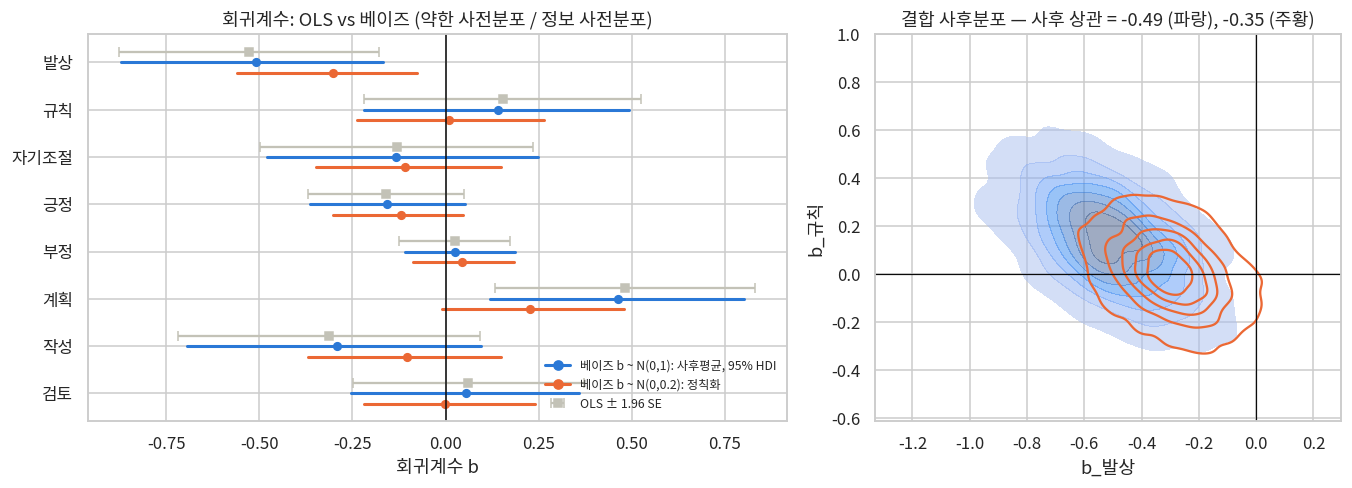

정칙화 후 b 사후SD (발상, 규칙, 자기조절): [0.123, 0.13, 0.127]  ← 약한 사전분포일 때: [0.178, 0.184, 0.183]


In [33]:
tab10s, R2_post_s = reg_summary(post_reg_s)
b1, b2 = flat(post_reg, "b"), flat(post_reg_s, "b")
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
ys = np.arange(8)
axes[0].errorbar(B_ols[1:], ys - .22, xerr=1.96 * SE_ols[1:], fmt="s", color=GRAY, ecolor=GRAY, ms=5, capsize=3, label="OLS ± 1.96 SE")
for j in range(8):
    lo, hi = hdi(b1[:, j]); axes[0].plot([lo, hi], [j, j], color=BLUE, lw=2); axes[0].plot(b1[:, j].mean(), j, "o", color=BLUE, ms=5)
    lo, hi = hdi(b2[:, j]); axes[0].plot([lo, hi], [j + .22, j + .22], color=ORANGE, lw=2); axes[0].plot(b2[:, j].mean(), j + .22, "o", color=ORANGE, ms=5)
axes[0].plot([], [], color=BLUE, lw=2, marker="o", label="베이즈 b ~ N(0,1): 사후평균, 95% HDI")
axes[0].plot([], [], color=ORANGE, lw=2, marker="o", label="베이즈 b ~ N(0,0.2): 정칙화")
axes[0].axvline(0, color=DARK, lw=1); axes[0].set(yticks=ys, yticklabels=names, xlabel="회귀계수 b", title="회귀계수: OLS vs 베이즈 (약한 사전분포 / 정보 사전분포)")
axes[0].invert_yaxis(); axes[0].legend(frameon=False, fontsize=8, loc="lower right")
# 다중공선성의 사후 표현: b_발상 과 b_규칙 의 결합 사후분포
i1, i2 = names.index("발상"), names.index("규칙")
sns.kdeplot(x=b1[:, i1], y=b1[:, i2], ax=axes[1], fill=True, color=BLUE, alpha=.5, levels=8, thresh=.05)
sns.kdeplot(x=b2[:, i1], y=b2[:, i2], ax=axes[1], color=ORANGE, levels=6, thresh=.05)
axes[1].axhline(0, color=DARK, lw=.8); axes[1].axvline(0, color=DARK, lw=.8)
axes[1].set(xlabel="b_발상", ylabel="b_규칙", title=f"결합 사후분포 — 사후 상관 = {np.corrcoef(b1[:, i1], b1[:, i2])[0,1]:.2f} (파랑), {np.corrcoef(b2[:, i1], b2[:, i2])[0,1]:.2f} (주황)")
plt.tight_layout(); plt.show()
print("정칙화 후 b 사후SD (발상, 규칙, 자기조절):", tab10s.loc[["발상", "규칙", "자기조절"], "b 사후SD"].round(3).tolist(),
      " ← 약한 사전분포일 때:", tab10.loc[["발상", "규칙", "자기조절"], "b 사후SD"].round(3).tolist())

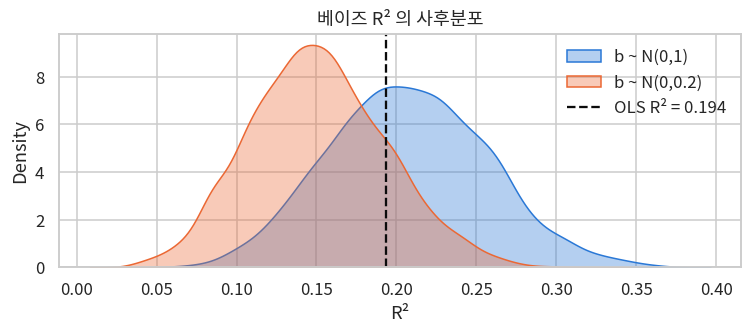

In [34]:
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.kdeplot(R2_post, ax=ax, fill=True, color=BLUE, alpha=.35, label="b ~ N(0,1)")
sns.kdeplot(R2_post_s, ax=ax, fill=True, color=ORANGE, alpha=.35, label="b ~ N(0,0.2)")
ax.axvline(R2_ols, color=DARK, ls="--", label=f"OLS R² = {R2_ols:.3f}")
ax.set(title="베이즈 R² 의 사후분포", xlabel="R²"); ax.legend(frameon=False); plt.tight_layout(); plt.show()

**읽기**. (1) 약한 사전분포($s_b=1$)의 사후평균과 HDI 는 OLS 추정치 ± 1.96 SE 와 거의 겹친다 — 자료가 사전분포를 압도한다는 뜻이고, 이때 베이즈의 이득은 "$P(b>0)=0.98$" 처럼 **직접 확률로 말할 수 있다**는 데 있다. (2) 결합 사후분포 그림에서 $b_{발상}$ 과 $b_{규칙}$ 이 길게 기울어진 타원을 이루는 것이 **다중공선성의 베이즈적 모습**이다: 자료는 두 계수의 합은 잘 알려 주지만 어떻게 나눌지는 모른다. VIF 라는 숫자 하나 대신 "무엇을 모르는지"가 그림으로 보인다. (3) 정보 사전분포($s_b=0.2$)는 그 타원을 원점 쪽으로 눌러 각 계수의 불확실성을 줄인다 — 논문에서 발상(−)과 규칙(+)의 부호가 갈린 현상은 이런 정칙화 아래서는 훨씬 약해진다. (4) OLS 의 $R^2$ 는 표본에 과적합된 값이라 베이즈 $R^2$ 사후분포의 중심보다 약간 크다.

**베이즈 논문이라면 <표 10> 을 이렇게 쓴다**: 열은 "b 사후평균, 사후SD, 95 % HDI, $P(b>0)$, β 사후평균", 표 아래에 "베이즈 $R^2$ = .16 [.08, .26]; 사전분포 $b\sim N(0,1)$, $\sigma\sim N^+(0,2)$; NUTS 4 체인 × 1000, 모든 R̂ ≤ 1.01, 발산 0". 그리고 민감도 분석으로 "사전분포를 $N(0,0.2)$ 로 바꾸어도 결론(긍정 호감도 계수의 부호)이 유지됨"을 한 문장 덧붙인다.

## 9. 정리 — 베이즈 논문의 결과 보고 체크리스트

| 항목 | 논문(빈도주의)에서는 | 베이즈 보고에서는 |
|---|---|---|
| 모형 | "SPSS 27.0 으로 상관·분산분석·회귀" | 우도와 **사전분포**를 수식으로 명시 (예: $\mu\sim N(3,2)$, $\Omega\sim$ LKJ(2)) |
| 계산 | — | 샘플러(NUTS), 체인 수, 반복 수, 소프트웨어와 버전 |
| 수렴 | — | 모든 모수의 R̂ ≤ 1.01, ESS ≥ 400, 발산 0; 부록에 trace plot |
| 추정치 | M, r, B, α (점) | 사후평균(또는 중앙값) **+ 95 % HDI** |
| 불확실성 | S.E. (일부만) | 사후 SD, HDI — 모든 양에 대해 |
| 유의성 | p, 별표, F | $P(\theta>0\mid D)$, ROPE 확률; 검정보다 **추정**과 **효과크기** |
| 집단 비교 | ANOVA + Scheffé | 차이 $\delta$ 의 사후분포 forest plot |
| 회귀 진단 | VIF, D–W | 계수의 사후 상관, 사후예측검사, 사전분포 민감도 분석 |
| 그림 | 없음 | 사후분포 밀도, forest plot, 사후예측검사 |

이 노트북에서 사후평균이 논문의 점추정치와 거의 같았던 것은 $N=172$ 와 약한 사전분포 때문이다. 베이즈가 바꾸는 것은 숫자 자체보다 **그 숫자에 대해 할 수 있는 말**이다 — "발상 효능감의 모평균 μ 가 [3.17, 3.39] 안에 있을 확률 95 %", "고급 학습자의 부정적 호감도가 초급보다 높을 확률 > 99.9 %", "α 가 0.8 을 넘을 확률 1.00". 그리고 표본이 작거나(2문항 척도), 변수가 얽혀 있을 때(다중공선성) 사전분포가 실제로 결과를 안정시키는 방식을 회귀 절에서 확인했다.